# Gompertz fit

In [8]:
# (1) Paths (edit here)
DATA_PATH = "../data/global40.dta"
BASE_DIR  = "../results/f2_gompertz"

import os
TAB_DIR       = os.path.join(BASE_DIR, "table")
SURV_FIGDIR   = os.path.join(BASE_DIR, "survival_pdf")
HAZ_FIGDIR    = os.path.join(BASE_DIR, "hazard_pdf")
CHZ_FIGDIR    = os.path.join(BASE_DIR, "cumhaz_pdf")
CDF_FIGDIR    = os.path.join(BASE_DIR, "cdf_pdf")
GLOBAL_FIGDIR = os.path.join(BASE_DIR, "global_curve_pdf")

for d in [BASE_DIR, TAB_DIR, SURV_FIGDIR, HAZ_FIGDIR, CHZ_FIGDIR, CDF_FIGDIR, GLOBAL_FIGDIR]:
    os.makedirs(d, exist_ok=True)

print("DATA_PATH:", DATA_PATH)
print("BASE_DIR :", BASE_DIR)

DATA_PATH: ../data/global40.dta
BASE_DIR : ../results/f2_gompertz


In [9]:
# (2) Dependencies

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple
from scipy.optimize import minimize
import autograd.numpy as anp
from autograd import grad, hessian

print("OK: imports done.")


OK: imports done.


In [10]:
# (3) Settings
START_AGE   = 50
AGE_MAX     = 100
AGE_STEP    = 1
MIN_N       = 200
MIN_EVENTS  = 10
REPORT_AGES = [a for a in [60, 70, 80, 90, 100] if START_AGE <= a <= AGE_MAX]
DISEASE_COLS = ["rlung", "rarthr", "rstrok", "rheart", "ralzhe", "rcancr"]

W_INCH_DOUBLE = 7.0
H_INCH_DOUBLE = 4.0
W_INCH_SINGLE = 3.4
H_INCH_SINGLE = 2.4
DPI_OUT = 600
FONT_SIZE = 9

W_CM = W_INCH_DOUBLE * 2.54
H_CM = H_INCH_DOUBLE * 2.54

AGE_GRID = np.arange(START_AGE, AGE_MAX + 1e-9, AGE_STEP)
T_GRID   = AGE_GRID - START_AGE

print("START_AGE:", START_AGE, "AGE_MAX:", AGE_MAX, "N ages:", len(AGE_GRID))

START_AGE: 50 AGE_MAX: 100 N ages: 51


In [11]:
# (4) Utilities
def trapz(x: np.ndarray, y: np.ndarray) -> float:
    if len(x) < 2 or len(y) < 2:
        return np.nan
    dx = np.diff(x)
    avg_y = (y[:-1] + y[1:]) / 2.0
    return float(np.sum(avg_y * dx))

def find_quantile_age(age: np.ndarray, surv: np.ndarray, p_surv: float = 0.5) -> float:
    if len(age) != len(surv) or np.all(pd.isna(surv)):
        return np.nan
    idx = np.where(surv <= p_surv)[0]
    if len(idx) == 0:
        return np.nan
    i = idx[0]
    if i == 0:
        return float(age[0])
    x1, x2 = age[i - 1], age[i]
    y1, y2 = surv[i - 1], surv[i]
    if np.isnan(y1) or np.isnan(y2) or y1 == y2:
        return float(age[i])
    return float(x1 + (p_surv - y1) * (x2 - x1) / (y2 - y1))

print("OK: utilities ready.")


OK: utilities ready.


In [12]:
# (5) Gompertz model (2 parameters)
# h(t)=lambda*exp(gamma*t); H(t)=(lambda/gamma)*(exp(gamma*t)-1); S(t)=exp(-H(t))

def gompertz_cumhaz(t, gamma, log_lambda):
    lambda_param = anp.exp(log_lambda)
    return (lambda_param / gamma) * anp.expm1(gamma * t)

def gompertz_hazard(t, gamma, log_lambda):
    return anp.exp(log_lambda) * anp.exp(gamma * t)

def gompertz_curves(params: np.ndarray, t_grid: np.ndarray) -> Dict[str, np.ndarray]:
    """Compute Gompertz curves given parameters (gamma, log_lambda) and time grid."""
    gamma, log_lambda = params[0], params[1]
    H = gompertz_cumhaz(t_grid, gamma, log_lambda)
    h = gompertz_hazard(t_grid, gamma, log_lambda)
    S = anp.exp(-H)
    return {"surv": np.asarray(S), "hazard": np.asarray(h), "cumhaz": np.asarray(H), "cdf": np.asarray(1.0 - S)}

def neg_loglik(theta, entry_t, exit_t, event):
    """Negative log-likelihood with left truncation.
    theta = [loglambda, loggamma]
    """
    loglambda, loggamma = theta
    log_lambda = loglambda
    gamma = anp.exp(loggamma)

    H_exit = gompertz_cumhaz(exit_t, gamma, log_lambda)
    H_entry = gompertz_cumhaz(entry_t, gamma, log_lambda)

    logS_exit = -H_exit
    logS_entry = -H_entry

    h_exit = gompertz_hazard(exit_t, gamma, log_lambda)

    return -anp.sum(event * anp.log(h_exit + 1e-12) + logS_exit - logS_entry)

_grad_nll = grad(neg_loglik)
_hess_nll = hessian(neg_loglik)

def fit_gompertz(entry_t, exit_t, event, init=None, maxiter=2000):
    if init is None:
        init = np.array([np.log(0.01), np.log(0.01)])

    bounds = [
        (np.log(1e-12), np.log(1.0)),
        (np.log(1e-12), np.log(1.0)),
    ]

    res = minimize(
        fun=lambda th: float(neg_loglik(th, entry_t, exit_t, event)),
        x0=init,
        jac=lambda th: np.asarray(_grad_nll(th, entry_t, exit_t, event)),
        method="L-BFGS-B",
        bounds=bounds,
        options={"maxiter": maxiter},
    )

    theta_hat = res.x
    loglambda, loggamma = theta_hat
    log_lambda = float(loglambda)
    gamma = float(np.exp(loggamma))
    params = np.array([gamma, log_lambda])

    cov_theta = None
    try:
        hess = np.asarray(_hess_nll(theta_hat, entry_t, exit_t, event))
        cov_theta = np.linalg.inv(hess)
    except Exception:
        cov_theta = None

    cov_params = None
    if cov_theta is not None and np.all(np.isfinite(cov_theta)):
        J = np.array([
            [0.0, gamma],
            [1.0, 0.0],
        ])
        cov_params = J @ cov_theta @ J.T

    return params, cov_params, res

def simulate_ci(params: np.ndarray, cov: np.ndarray, t_grid: np.ndarray, n_sim: int = 1000, seed: int = 1):
    """Parametric simulation CI using MVN(params, cov) on (gamma, log_lambda)."""
    if cov is None or np.any(np.isnan(cov)):
        return None
    rng = np.random.default_rng(seed)
    sim = rng.multivariate_normal(mean=params, cov=cov, size=n_sim)

    surv   = np.zeros((n_sim, len(t_grid)))
    haz    = np.zeros_like(surv)
    cumhaz = np.zeros_like(surv)
    cdf    = np.zeros_like(surv)

    for i in range(n_sim):
        curves   = gompertz_curves(sim[i], t_grid)
        surv[i]   = curves["surv"]
        haz[i]    = curves["hazard"]
        cumhaz[i] = curves["cumhaz"]
        cdf[i]    = curves["cdf"]

    def q(x):
        return np.nanpercentile(x, [2.5, 97.5], axis=0)

    return {"surv": q(surv), "hazard": q(haz), "cumhaz": q(cumhaz), "cdf": q(cdf)}

print("OK: Gompertz functions ready.")


OK: Gompertz functions ready.


In [13]:
# (6) Plot helpers
def theme_std(ax: plt.Axes, font_size: int = 9):
    """Nature journal standard theme: clean, sans-serif, minimal"""
    ax.set_facecolor("white")
    ax.tick_params(axis="both", labelsize=font_size, width=0.5, length=2.5)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.5)
        spine.set_color("black")
    ax.xaxis.label.set_fontsize(font_size)
    ax.yaxis.label.set_fontsize(font_size)
    if ax.get_title():
        ax.title.set_fontsize(font_size)

def save_plot(fig: plt.Figure, path: str):
    base, _ = os.path.splitext(path)
    pdf_path = f"{base}.pdf"
    fig.savefig(pdf_path, dpi=DPI_OUT, bbox_inches="tight", facecolor='white', edgecolor='none')
    plt.close(fig)

print("OK: plotting helpers ready.")


OK: plotting helpers ready.


In [14]:
# (7) Load & clean data
raw = pd.read_stata(DATA_PATH)

raw = (
    raw.assign(
        id=raw["id"].astype(str),
        age=pd.to_numeric(raw["ragey_b"], errors="coerce"),
        country=raw["isocountry_c"].astype(str),
        continent=raw["continent_c"].astype(str),
        rwalk1a=pd.to_numeric(raw["rwalk1a"], errors="coerce"),
        ragender=pd.to_numeric(raw.get("ragender"), errors="coerce"),
        rurbrur=pd.to_numeric(raw.get("rurbrur"), errors="coerce"),
        rlung=pd.to_numeric(raw.get("rlung"), errors="coerce"),
        rarthr=pd.to_numeric(raw.get("rarthr"), errors="coerce"),
        rstrok=pd.to_numeric(raw.get("rstrok"), errors="coerce"),
        rheart=pd.to_numeric(raw.get("rheart"), errors="coerce"),
        ralzhe=pd.to_numeric(raw.get("ralzhe"), errors="coerce"),
        rcancr=pd.to_numeric(raw.get("rcancr"), errors="coerce"),
    )
    .loc[:, [
        "id", "age", "country", "continent", "rwalk1a", "ragender", "rurbrur",
        "rlung", "rarthr", "rstrok", "rheart", "ralzhe", "rcancr",
    ]]
    .dropna(subset=["id", "country", "age"])
    .loc[lambda d: d["country"].str.strip() != "", :]
 )

raw["rwalk1a"] = raw["rwalk1a"].where(raw["rwalk1a"].isin([0, 1]))
raw["ragender"] = raw["ragender"].where(raw["ragender"].isin([1, 2]))
raw["rurbrur"] = raw["rurbrur"].where(raw["rurbrur"].isin([0, 1]))
for c in DISEASE_COLS:
    raw[c] = raw[c].where(raw[c].isin([0, 1]))

print("raw shape:", raw.shape)
print("countries:", raw["country"].nunique())
print(sorted(raw["country"].astype(str).unique()))
raw.head()


raw shape: (1206788, 13)
countries: 40
['Australia', 'Austria', 'Belgium', 'Brazil', 'Bulgaria', 'China', 'Costa Rica', 'Croatia', 'Cyprus', 'Czech Republic', 'Denmark', 'England', 'Estonia', 'Finland', 'France', 'Germany', 'Greece', 'Hungary', 'India', 'Ireland', 'Israel', 'Italy', 'Japan', 'Korea', 'Latvia', 'Lithuania', 'Luxembourg', 'Malta', 'Mexico', 'Netherlands', 'Poland', 'Portugal', 'Romania', 'Slovakia', 'Slovenia', 'South Africa', 'Spain', 'Sweden', 'Switzerland', 'USA']


,id,age,country,continent,rwalk1a,ragender,rurbrur,rlung,rarthr,rstrok,rheart,ralzhe,rcancr
0,1.0,73.0,Australia,Oceania,0.0,NaN,1.0,NaN,0.0,0.0,1.0,NaN,0.0
1,1.0,75.0,Australia,Oceania,1.0,NaN,NaN,0.0,0.0,0.0,1.0,0.0,0.0
2,1.0,75.0,Australia,Oceania,1.0,NaN,1.0,0.0,0.0,0.0,0.0,NaN,1.0
3,1.0,77.0,Australia,Oceania,1.0,NaN,NaN,0.0,0.0,0.0,1.0,NaN,0.0
4,2.0,73.0,Australia,Oceania,0.0,NaN,1.0,NaN,0.0,0.0,0.0,NaN,0.0


In [15]:
# (8) Build person-level data
processed_parquet = os.path.join(os.path.dirname(DATA_PATH), "person_left_trunc.parquet")
processed_csv = os.path.join(os.path.dirname(DATA_PATH), "person_left_trunc.csv")

if os.path.exists(processed_parquet):
    print("Found parquet, trying to load:", processed_parquet)
    try:
        person = pd.read_parquet(processed_parquet)
        print("Loaded parquet file.")
    except Exception as e:
        print("Warning: failed to read parquet (pyarrow/fastparquet may be missing); falling back to CSV. Error:", str(e))
        if os.path.exists(processed_csv):
            person = pd.read_csv(processed_csv)
            print("Loaded CSV file.")
        else:
            print("No CSV available; will build from raw data.")
            person = None
elif os.path.exists(processed_csv):
    print("Loading preprocessed CSV:", processed_csv)
    person = pd.read_csv(processed_csv)
else:
    person = None

if person is not None:
    missing = {"country", "id"} - set(person.columns)
    if missing:
        print("Preprocessed person file missing columns:", sorted(missing))
        print("Rebuilding person-level data from raw.")
        person = None

if person is None:
    print("Preprocessed file not found — building person-level data from raw.")

    person_rows: List[Dict] = []

    for (country, pid), g in raw.sort_values(["country", "id", "age"]).groupby(["country", "id"]):
        cont = g["continent"].dropna().iloc[0] if g["continent"].notna().any() else np.nan

        valid = g.loc[g["rwalk1a"].notna(), :]
        if valid.empty:
            continue

        baseline_valid_age = valid["age"].min()
        baseline_state     = valid.iloc[0]["rwalk1a"]
        censor_age         = valid["age"].max()
        event_age          = valid.loc[valid["rwalk1a"] == 1, "age"].min() if (valid["rwalk1a"] == 1).any() else np.nan

        if pd.isna(baseline_state) or baseline_state != 0:
            continue
        if pd.isna(baseline_valid_age) or pd.isna(censor_age) or censor_age <= baseline_valid_age:
            continue
        if censor_age <= START_AGE:
            continue

        censor_age_w = min(censor_age, AGE_MAX)
        event_w      = 1 if (not pd.isna(event_age) and event_age <= AGE_MAX) else 0
        exit_age     = event_age if event_w == 1 else censor_age_w

        entry_age = min(max(baseline_valid_age, START_AGE), AGE_MAX)
        exit_age  = min(exit_age, AGE_MAX)

        entry_t = entry_age - START_AGE
        exit_t  = exit_age  - START_AGE

        if pd.isna(entry_t) or pd.isna(exit_t) or exit_t <= entry_t:
            continue

        person_rows.append(dict(
            country=str(country),
            continent=str(cont),
            id=str(pid),
            entry_age=entry_age,
            exit_age=exit_age,
            entry_t=entry_t,
            exit_t=exit_t,
            event_w=event_w,
            baseline_valid_age=baseline_valid_age,
        ))

    person = pd.DataFrame(person_rows)

    os.makedirs(os.path.dirname(processed_csv), exist_ok=True)
    try:
        print(f"Saving parquet to: {processed_parquet}")
        person.to_parquet(processed_parquet, index=False)
    except Exception:
        print("Warning: parquet write failed (pyarrow/fastparquet may be missing). Saving CSV instead and advising install.")
        print("To enable parquet support, install pyarrow: pip install pyarrow")
        print(f"Saving csv to: {processed_csv}")
        person.to_csv(processed_csv, index=False)
    else:
        print(f"Saving csv to: {processed_csv}")
        person.to_csv(processed_csv, index=False)

print("person rows:", person.shape[0])
person.head()


Loading preprocessed CSV: ../data/person_left_trunc.csv
person rows: 193731


,country,continent,id,entry_age,exit_age,entry_t,exit_t,event_w,baseline_valid_age
0,Australia,Oceania,1.0,73.0,75.0,23.0,25.0,1,73.0
1,Australia,Oceania,10.0,80.0,82.0,30.0,32.0,0,80.0
2,Australia,Oceania,100.0,66.0,78.0,16.0,28.0,1,66.0
3,Australia,Oceania,1000.0,80.0,82.0,30.0,32.0,0,80.0
4,Australia,Oceania,1001.0,81.0,85.0,31.0,35.0,0,81.0


In [16]:
# (8a) Export included individuals (globaloa.csv)
if "person" not in globals() or person is None or person.empty:
    print("person is empty. Run the person-level build cell first.")
else:
    include_ids = person[["country", "id"]].dropna().drop_duplicates()
    include_ids = include_ids.assign(
        country=include_ids["country"].astype(str),
        id=include_ids["id"].astype(str),
    )
    raw_merge = raw.assign(
        country=raw["country"].astype(str),
        id=raw["id"].astype(str),
    )
    globaloa = raw_merge.merge(include_ids, on=["country", "id"], how="inner")
    out_path = os.path.join(BASE_DIR, "globaloa.csv")
    globaloa.to_csv(out_path, index=False)
    print("Saved:", out_path)

Saved: ../results/f2_gompertz/globaloa.csv


In [17]:
# Check countries used in fit (MIN_N/MIN_EVENTS)
countries_raw = sorted(raw["country"].dropna().astype(str).str.strip().unique().tolist())
by_cty = (
    person.groupby("country", dropna=False)
    .agg(n=("event_w", "size"), events=("event_w", "sum"))
    .reset_index()
 )
by_cty["country"] = by_cty["country"].astype(str).str.strip()
used = by_cty.loc[(by_cty["n"] >= MIN_N) & (by_cty["events"] >= MIN_EVENTS), "country"].tolist()
used_set = set(used)
not_used = [c for c in countries_raw if c not in used_set]
print("Countries used in fit:", len(used))
print("Countries not used:", not_used)

Countries used in fit: 36
Countries not used: ['Brazil', 'Costa Rica', 'Ireland', 'South Africa']


In [18]:
# # (8e) Diagnose country inclusion
# target_countries = ["Costa Rica"]

# def diagnose_country(country_name: str):
#     df = raw.loc[raw["country"].astype(str).str.strip() == country_name].copy()
#     if df.empty:
#         print("Country not found in raw:", country_name)
#         return
#     reasons = []
#     rows = []
#     for (ctry, pid), g in df.sort_values(["country", "id", "age"]).groupby(["country", "id"]):
#         valid = g.loc[g["rwalk1a"].notna(), :]
#         if valid.empty:
#             reasons.append("no_valid_rwalk1a")
#             continue
#         baseline_state = valid.iloc[0]["rwalk1a"]
#         baseline_valid_age = valid["age"].min()
#         censor_age = valid["age"].max()
#         event_age = valid.loc[valid["rwalk1a"] == 1, "age"].min() if (valid["rwalk1a"] == 1).any() else np.nan

#         if pd.isna(baseline_state) or baseline_state != 0:
#             reasons.append("baseline_not_zero")
#             continue
#         if pd.isna(baseline_valid_age) or pd.isna(censor_age) or censor_age <= baseline_valid_age:
#             reasons.append("bad_followup")
#             continue
#         if censor_age <= START_AGE:
#             reasons.append("censor_before_start")
#             continue

#         censor_age_w = min(censor_age, AGE_MAX)
#         event_w = 1 if (not pd.isna(event_age) and event_age <= AGE_MAX) else 0
#         exit_age = event_age if event_w == 1 else censor_age_w
#         entry_age = min(max(baseline_valid_age, START_AGE), AGE_MAX)
#         exit_age = min(exit_age, AGE_MAX)
#         entry_t = entry_age - START_AGE
#         exit_t = exit_age - START_AGE
#         if pd.isna(entry_t) or pd.isna(exit_t) or exit_t <= entry_t:
#             reasons.append("invalid_interval")
#             continue

#         rows.append({"country": str(ctry), "id": str(pid), "event_w": event_w})
#         reasons.append("included")

#     reason_counts = pd.Series(reasons).value_counts().rename_axis("reason").reset_index(name="n_ids")
#     print("Country:", country_name)
#     print("Raw rows:", len(df), "Unique ids:", df["id"].nunique())
#     print(reason_counts)
#     if rows:
#         tmp = pd.DataFrame(rows)
#         n = len(tmp)
#         e = int(tmp["event_w"].sum())
#         print("Included n:", n, "events:", e, "MIN_N:", MIN_N, "MIN_EVENTS:", MIN_EVENTS)
#     else:
#         print("Included n: 0")

# for c in target_countries:
#     diagnose_country(c)

In [19]:
# (9) QC table by country
qc = (
    person.groupby(["country", "continent"], dropna=False)
    .agg(
        n=("event_w", "size"),
        events=("event_w", "sum"),
        censored=("event_w", lambda x: int((x == 0).sum())),
        baseline_age_min=("baseline_valid_age", "min"),
        baseline_age_med=("baseline_valid_age", "median"),
        entry_age_min=("entry_age", "min"),
        entry_age_med=("entry_age", "median"),
        exit_age_max=("exit_age", "max"),
    )
    .reset_index()
    .sort_values("n", ascending=False)
)

qc_path = os.path.join(TAB_DIR, "qc_counts_by_country.csv")
qc.to_csv(qc_path, index=False)
print("Saved QC:", qc_path)
qc.head(10)


Saved QC: ../results/f2_gompertz/table/qc_counts_by_country.csv


,country,continent,n,events,censored,baseline_age_min,baseline_age_med,entry_age_min,entry_age_med,exit_age_max
35,USA,North America,32935,11262,21673,25.0,55.0,50.0,55.0,100.0
4,China,Asia,17999,2166,15833,43.0,57.0,50.0,57.0,100.0
25,Mexico,North America,16507,3635,12872,21.0,57.0,50.0,57.0,100.0
9,England,Europe,13620,2781,10839,36.0,59.0,50.0,59.0,90.0
20,Korea,Asia,9359,1490,7869,45.0,59.0,50.0,59.0,100.0
2,Belgium,Europe,6918,1203,5715,37.0,59.0,50.0,59.0,100.0
32,Spain,Europe,6197,1350,4847,41.0,63.0,50.0,63.0,100.0
10,Estonia,Europe,6181,1460,4721,41.0,62.0,50.0,62.0,100.0
12,France,Europe,5899,1021,4878,35.0,60.0,50.0,60.0,100.0
13,Germany,Europe,5877,849,5028,38.0,61.0,50.0,61.0,100.0


In [20]:
# (10) Fit Gompertz by country
# Covariance transform handled in fit_gompertz
FILL_CI = "#d4e6f1"
LINE_COL = "#2874a6"
FILL_GM = "#d5f4e6"
LINE_GM = "#186a3b"

@dataclass
class CountryResult:
    ok: bool
    country: str
    continent: str
    pars: Optional[pd.DataFrame] = None
    metrics: Optional[pd.DataFrame] = None
    pred: Optional[pd.DataFrame] = None
    haz: Optional[pd.DataFrame] = None
    cumhaz: Optional[pd.DataFrame] = None
    cdf: Optional[pd.DataFrame] = None
    person_data: Optional[pd.DataFrame] = None

def rmst_ci_from_params(
    params: np.ndarray,
    cov: Optional[np.ndarray],
    t_grid: np.ndarray,
    age_grid: np.ndarray,
    start_age: float,
    n_sim: int = 1000,
    seed: int = 1,
    ) -> Tuple[float, float]:
    if cov is None or np.any(np.isnan(cov)):
        return (np.nan, np.nan)
    rng = np.random.default_rng(seed)
    sim = rng.multivariate_normal(mean=params, cov=cov, size=n_sim)
    rmst_vals = np.zeros(n_sim)
    for i in range(n_sim):
        curves = gompertz_curves(sim[i], t_grid)
        surv_vals = np.clip(curves["surv"], 0, 1)
        rmst_vals[i] = start_age + trapz(age_grid, surv_vals)
    lcl, ucl = np.nanpercentile(rmst_vals, [2.5, 97.5])
    return (float(lcl), float(ucl))

results = []
fail_list = []

for country in sorted(person["country"].unique()):
    try:
        df_cty = person[person["country"] == country].copy()
        cont = df_cty["continent"].iloc[0]
        n = len(df_cty)
        e = int(df_cty["event_w"].sum())
        cens = n - e

        if n < MIN_N or e < MIN_EVENTS:
            fail_list.append(country)
            continue

        entry_t = df_cty["entry_t"].values
        exit_t = df_cty["exit_t"].values
        event = df_cty["event_w"].values.astype(int)

        params, cov, res = fit_gompertz(entry_t, exit_t, event)

        gamma, log_lambda = params
        lambda_est = float(np.exp(log_lambda))

        curves = gompertz_curves(params, T_GRID)
        ci = simulate_ci(params, cov, T_GRID, n_sim=1000, seed=hash(country) % 10000)

        pred_df = pd.DataFrame({
            "country": country,
            "age": AGE_GRID,
            "surv": curves["surv"],
            "lower": ci["surv"][0] if ci else np.nan,
            "upper": ci["surv"][1] if ci else np.nan,
        })

        haz_df = pd.DataFrame({
            "country": country,
            "age": AGE_GRID,
            "hazard": curves["hazard"],
            "lower": ci["hazard"][0] if ci else np.nan,
            "upper": ci["hazard"][1] if ci else np.nan,
        })

        cumhaz_df = pd.DataFrame({
            "country": country,
            "age": AGE_GRID,
            "cumhaz": curves["cumhaz"],
            "lower": ci["cumhaz"][0] if ci else np.nan,
            "upper": ci["cumhaz"][1] if ci else np.nan,
        })

        cdf_df = pd.DataFrame({
            "country": country,
            "age": AGE_GRID,
            "cdf": curves["cdf"],
            "lower": ci["cdf"][0] if ci else np.nan,
            "upper": ci["cdf"][1] if ci else np.nan,
        })

        surv_vals = np.clip(curves["surv"], 0, 1)
        rmst_years = START_AGE + trapz(AGE_GRID, surv_vals)
        rmst_lcl, rmst_ucl = rmst_ci_from_params(
            params, cov, T_GRID, AGE_GRID, START_AGE, n_sim=1000, seed=hash(country) % 10000
        )

        q10_age = find_quantile_age(AGE_GRID, surv_vals, p_surv=0.10)
        q25_age = find_quantile_age(AGE_GRID, surv_vals, p_surv=0.75)
        q50_age = find_quantile_age(AGE_GRID, surv_vals, p_surv=0.50)
        q75_age = find_quantile_age(AGE_GRID, surv_vals, p_surv=0.25)

        iqr_survival = q75_age - q25_age
        high_width = q10_age - q50_age

        metrics_dict = {
            "country": country,
            "continent": cont,
            "n": n,
            "events": e,
            "rmst": rmst_years,
            "rmst_lcl": rmst_lcl,
            "rmst_ucl": rmst_ucl,
            "t50": q50_age,
            "t_at_S_0_75": q25_age,
            "t_at_S_0_25": q75_age,
            "iqr_survival": iqr_survival,
            "high_width": high_width,
        }
        for age in REPORT_AGES:
            age_idx = np.searchsorted(AGE_GRID, age)
            if age_idx < len(AGE_GRID):
                metrics_dict[f"surv_at_{age}"] = surv_vals[age_idx]
                metrics_dict[f"haz_at_{age}"] = curves["hazard"][age_idx]

        metrics_df = pd.DataFrame([metrics_dict])

        if cov is not None and np.all(np.isfinite(cov)):
            gamma_se = np.sqrt(cov[0, 0])
            lambda_se = lambda_est * np.sqrt(cov[1, 1])
        else:
            gamma_se = np.nan
            lambda_se = np.nan

        gamma_est_r = np.round(gamma, 6)
        lambda_est_r = np.round(lambda_est, 6)

        pars_df = pd.DataFrame([{
            "country": country, "continent": cont, "n": n, "events": e, "censored": cens,
            "gamma_est": gamma_est_r, "gamma_se": gamma_se,
            "lambda_est": lambda_est_r, "lambda_se": lambda_se,
        }])

        person_country_df = pd.DataFrame({
            "entry_age": df_cty["entry_age"].values,
            "exit_age": df_cty["exit_age"].values,
            "event": df_cty["event_w"].values,
        })

        result = CountryResult(
            ok=True, country=country, continent=cont,
            pars=pars_df, metrics=metrics_df,
            pred=pred_df, haz=haz_df, cumhaz=cumhaz_df, cdf=cdf_df,
            person_data=person_country_df
        )

        results.append(result)

    except Exception as ex:
        fail_list.append(country)
        print(f"  {country}: {str(ex)[:60]}")

if fail_list:
    print(f"✗ Failed {len(fail_list)}: {fail_list[:5]}")

print(f"✓ Fitted {len([r for r in results if r.ok])} countries")

✓ Fitted 36 countries


In [21]:
# (11) Save parameter & metrics tables
pars_all = pd.concat([r.pars for r in results if r.pars is not None], ignore_index=True)
met_all  = pd.concat([r.metrics for r in results if r.metrics is not None], ignore_index=True)

pars_path = os.path.join(TAB_DIR, "gompertz_params_by_country.csv")
met_path  = os.path.join(TAB_DIR, "gompertz_derived_metrics_by_country.csv")

pars_all.to_csv(pars_path, index=False)
met_all.to_csv(met_path, index=False)

print("Saved:", pars_path)
print("Saved:", met_path)

pars_all.head()


Saved: ../results/f2_gompertz/table/gompertz_params_by_country.csv
Saved: ../results/f2_gompertz/table/gompertz_derived_metrics_by_country.csv


,country,continent,n,events,censored,gamma_est,gamma_se,lambda_est,lambda_se
0,Australia,Oceania,1460,771,689,0.088067,0.005801,0.004972,0.000979
1,Austria,Europe,4845,827,4018,0.100726,0.003841,0.002370,0.000256
2,Belgium,Europe,6918,1203,5715,0.083821,0.002832,0.004100,0.000307
3,Bulgaria,Europe,878,115,763,0.091078,0.010036,0.005009,0.001294
4,China,Asia,17999,2166,15833,0.083900,0.002181,0.006292,0.000299


In [22]:
# (12) Per-country plot functions 
def _safe_name(s: str) -> str:
    return "".join(c if c.isalnum() or c in "_-" else "_" for c in s)

def _km_curve(res: CountryResult) -> pd.DataFrame:
    if res.person_data is None or res.person_data.empty:
        return pd.DataFrame(columns=["age", "surv", "lower", "upper"])
    df = res.person_data.copy()
    df = df.dropna(subset=["entry_age", "exit_age", "event"])
    entry = df["entry_age"].to_numpy(dtype=float)
    exit_ = df["exit_age"].to_numpy(dtype=float)
    event = df["event"].to_numpy(dtype=int)
    event_times = np.sort(np.unique(exit_[event == 1]))
    if event_times.size == 0:
        return pd.DataFrame(columns=["age", "surv", "lower", "upper"])
    z = 1.96
    surv_vals = []
    lower_vals = []
    upper_vals = []
    ages = []
    s = 1.0
    v = 0.0
    for t in event_times:
        at_risk = (entry <= t) & (exit_ >= t)
        n_i = int(np.sum(at_risk))
        if n_i <= 0:
            continue
        d_i = int(np.sum((event == 1) & (exit_ == t)))
        if d_i <= 0:
            continue
        s *= (1.0 - d_i / n_i)
        if n_i > d_i:
            v += d_i / (n_i * (n_i - d_i))
        ages.append(t)
        surv_vals.append(s)
        if s <= 0 or s >= 1 or v <= 0:
            lower_vals.append(s)
            upper_vals.append(s)
        else:
            se_g = np.sqrt(v) / abs(np.log(s))
            g = np.log(-np.log(s))
            lower_vals.append(np.exp(-np.exp(g + z * se_g)))
            upper_vals.append(np.exp(-np.exp(g - z * se_g)))
    if len(ages) == 0:
        return pd.DataFrame(columns=["age", "surv", "lower", "upper"])
    km_df = pd.DataFrame({"age": ages, "surv": surv_vals, "lower": lower_vals, "upper": upper_vals})
    start_row = pd.DataFrame({"age": [START_AGE], "surv": [1.0], "lower": [1.0], "upper": [1.0]})
    km_df = pd.concat([start_row, km_df], ignore_index=True)
    return km_df

def _empirical_hazard(
    res: CountryResult,
    bin_width: int = 5,
    min_person_time: float = 100.0,
    min_events: int = 1,
    ) -> pd.DataFrame:
    if res.person_data is None or res.person_data.empty:
        return pd.DataFrame(columns=["age", "haz_emp"])
    df = res.person_data.copy()
    df = df.dropna(subset=["entry_age", "exit_age", "event"])
    start = START_AGE
    end = AGE_MAX
    bins = np.arange(start, end + bin_width, bin_width)
    out_rows = []
    for b0 in bins[:-1]:
        b1 = b0 + bin_width
        entry = df["entry_age"].to_numpy(dtype=float)
        exit_ = df["exit_age"].to_numpy(dtype=float)
        time_in_bin = np.maximum(0.0, np.minimum(exit_, b1) - np.maximum(entry, b0))
        person_time = float(np.sum(time_in_bin))
        if person_time < min_person_time:
            continue
        events = int(((df["event"] == 1) & (df["exit_age"] >= b0) & (df["exit_age"] < b1)).sum())
        if events < min_events:
            continue
        haz = events / person_time
        out_rows.append({"age": (b0 + b1) / 2.0, "haz_emp": haz})
    return pd.DataFrame(out_rows)

def plot_surv_one(res: CountryResult, show: bool = False):
    if not res.ok:
        return
    safe_cc = _safe_name(res.country)
    fit_df = res.pred.copy()
    km_df = _km_curve(res)

    def _build_surv_fig(show_labels: bool):
        fig, ax = plt.subplots(figsize=(W_INCH_SINGLE, H_INCH_SINGLE), dpi=600)
        ax.fill_between(fit_df["age"], fit_df["lower"], fit_df["upper"], color="#FE0100", alpha=0.2, linewidth=0)
        ax.plot(fit_df["age"], fit_df["surv"], color="#FE0100", linewidth=1.0, label="Gompertz")
        if not km_df.empty:
            ax.fill_between(
                km_df["age"],
                km_df["lower"],
                km_df["upper"],
                step="post",
                color="#1D5F9B",
                alpha=0.2,
                linewidth=0,
            )
            ax.step(km_df["age"], km_df["surv"], where="post", color="#1D5F9B", linewidth=0.9, label="Kaplan–Meier")

        q50_age = find_quantile_age(fit_df["age"].values, fit_df["surv"].values, p_surv=0.5)
        if np.isfinite(q50_age):
            ax.scatter([q50_age], [0.5], s=16, color="black", zorder=5)
            ax.vlines(q50_age, ymin=0, ymax=0.5, linestyles="--", colors="black", linewidth=0.8)
            ax.hlines(0.5, xmin=START_AGE, xmax=q50_age, linestyles="--", colors="black", linewidth=0.8)

        ax.set_xlim(START_AGE, AGE_MAX); ax.set_ylim(0, 1)
        if show_labels:
            ax.set_xlabel("Age (years)", fontsize=FONT_SIZE)
            ax.set_ylabel("Difficulty-free probability (%)", fontsize=FONT_SIZE)
        else:
            ax.set_xlabel("")
            ax.set_ylabel("")
        ax.set_yticks([0, 0.5, 1]); ax.set_yticklabels(["0", "50", "100"])
        xticks = [START_AGE, AGE_MAX]
        if np.isfinite(q50_age):
            if all(abs(q50_age - t) > 1e-6 for t in xticks):
                xticks.append(q50_age)
        xticks = sorted(xticks)
        ax.set_xticks(xticks)
        if np.isfinite(q50_age):
            xtick_labels = []
            for t in xticks:
                if abs(t - q50_age) < 1e-6:
                    xtick_labels.append(f"{q50_age:.2f}")
                else:
                    xtick_labels.append(f"{int(round(t))}")
            ax.set_xticklabels(xtick_labels)
        legend_loc = "lower left" 
        ax.legend(loc=legend_loc, frameon=False, fontsize=FONT_SIZE-1)
        theme_std(ax, font_size=FONT_SIZE)
        plt.tight_layout()
        return fig

    fig = _build_surv_fig(show_labels=True)
    if show:
        plt.show()
    save_plot(fig, os.path.join(SURV_FIGDIR, f"gompertz_survival_{safe_cc}.pdf"))

    fig_xy = _build_surv_fig(show_labels=False)
    if show:
        plt.show()
    save_plot(fig_xy, os.path.join(SURV_FIGDIR, f"gompertz_survival_{safe_cc}_xy.pdf"))

def plot_haz_one(res: CountryResult, show: bool = False):
    if not res.ok:
        return
    safe_cc = _safe_name(res.country)
    df = res.haz.copy()
    emp = _empirical_hazard(res, bin_width=5, min_person_time=100.0, min_events=1)
    fig, ax = plt.subplots(figsize=(W_INCH_SINGLE, H_INCH_SINGLE), dpi=600)
    ax.fill_between(df["age"], df["lower"], df["upper"], color=FILL_CI, alpha=0.20)
    ax.plot(df["age"], df["hazard"], color="#FFB900", linewidth=1.0, label="Gompertz hazard")
    if not emp.empty:
        ax.scatter(
            emp["age"],
            emp["haz_emp"],
            s=12,
            color="#0078FF",
            alpha=0.7,
            label="Empirical hazard (5y bins)",
            zorder=6,
            edgecolors="none",
            linewidths=0,
        )
    ax.set_xlim(START_AGE, AGE_MAX)
    ax.set_xlabel("Age (years)", fontsize=FONT_SIZE)
    ax.set_ylabel("Hazard h(age)", fontsize=FONT_SIZE)
    ax.set_xticks([START_AGE, AGE_MAX])
    ax.legend(loc="best", frameon=False, fontsize=FONT_SIZE-1)
    theme_std(ax, font_size=FONT_SIZE)
    plt.tight_layout()
    if show:
        plt.show()
    save_plot(fig, os.path.join(HAZ_FIGDIR, f"gompertz_hazard_{safe_cc}.pdf"))

def plot_cumhaz_one(res: CountryResult, show: bool = False):
    if not res.ok:
        return
    safe_cc = _safe_name(res.country)
    df = res.cumhaz.copy()
    fig, ax = plt.subplots(figsize=(W_INCH_SINGLE, H_INCH_SINGLE), dpi=600)
    ax.fill_between(df["age"], df["lower"], df["upper"], color=FILL_CI, alpha=0.20)
    ax.plot(df["age"], df["cumhaz"], color=LINE_COL, linewidth=1.0, label="Gompertz cumhaz")
    ax.set_xlim(START_AGE, AGE_MAX)
    ax.set_xlabel("Age (years)", fontsize=FONT_SIZE)
    ax.set_ylabel("Cumulative hazard H(age)", fontsize=FONT_SIZE)
    ax.set_xticks([START_AGE, AGE_MAX])
    ax.legend(loc="best", frameon=False, fontsize=FONT_SIZE-1)
    theme_std(ax, font_size=FONT_SIZE)
    plt.tight_layout()
    if show:
        plt.show()
    save_plot(fig, os.path.join(CHZ_FIGDIR, f"gompertz_cumhaz_{safe_cc}.pdf"))

def plot_cdf_one(res: CountryResult, show: bool = False):
    if not res.ok:
        return
    safe_cc = _safe_name(res.country)
    df = res.cdf.copy()
    fig, ax = plt.subplots(figsize=(W_INCH_SINGLE, H_INCH_SINGLE), dpi=600)
    ax.fill_between(df["age"], df["lower"], df["upper"], color=FILL_CI, alpha=0.20)
    ax.plot(df["age"], df["cdf"], color=LINE_COL, linewidth=1.0, label="Gompertz CDF")
    ax.set_xlim(START_AGE, AGE_MAX); ax.set_ylim(0, 1)
    ax.set_xlabel("Age (years)", fontsize=FONT_SIZE)
    ax.set_ylabel("CDF F(age) (%)", fontsize=FONT_SIZE)
    ax.set_yticks([0, 0.5, 1]); ax.set_yticklabels(["0", "50", "100"])
    ax.set_xticks([START_AGE, AGE_MAX])
    ax.legend(loc="best", frameon=False, fontsize=FONT_SIZE-1)
    theme_std(ax, font_size=FONT_SIZE)
    plt.tight_layout()
    if show:
        plt.show()
    save_plot(fig, os.path.join(CDF_FIGDIR, f"gompertz_cdf_{safe_cc}.pdf"))

print("OK: plot functions defined.")

# Example plots (one country)
example_country = pars_all.sort_values("n", ascending=False).iloc[0]["country"]
res = next(r for r in results if r.ok and r.country == example_country)

# plot_surv_one(res, show=True)
# plot_haz_one(res, show=True)
# plot_cumhaz_one(res, show=True)
# plot_cdf_one(res, show=True)

# print("Example plots shown for:", example_country)

# Generate country PDFs
for r in results:
    plot_surv_one(r)
    plot_haz_one(r)
    plot_cumhaz_one(r)
    plot_cdf_one(r)

print("Country plots saved.")

OK: plot functions defined.
Country plots saved.


Population weights (latest available year):
       country iso3  year    population weight
         India  IND  2024 1,450,935,791 35.68%
         China  CHN  2024 1,408,975,000 34.65%
           USA  USA  2024   340,110,988  8.36%
        Mexico  MEX  2024   130,861,007  3.22%
         Japan  JPN  2024   123,975,371  3.05%
       Germany  DEU  2024    83,516,593  2.05%
       England  GBR  2024    69,226,000  1.70%
        France  FRA  2024    68,551,653  1.69%
         Italy  ITA  2024    58,952,704  1.45%
         Korea  KOR  2024    51,751,065  1.27%
         Spain  ESP  2024    48,848,840  1.20%
        Poland  POL  2024    36,559,233  0.90%
     Australia  AUS  2024    27,196,812  0.67%
       Romania  ROU  2024    19,051,804  0.47%
   Netherlands  NLD  2024    17,993,485  0.44%
       Belgium  BEL  2024    11,858,610  0.29%
Czech Republic  CZE  2024    10,905,028  0.27%
      Portugal  PRT  2024    10,694,681  0.26%
        Sweden  SWE  2024    10,569,709  0.26%
        Greece  

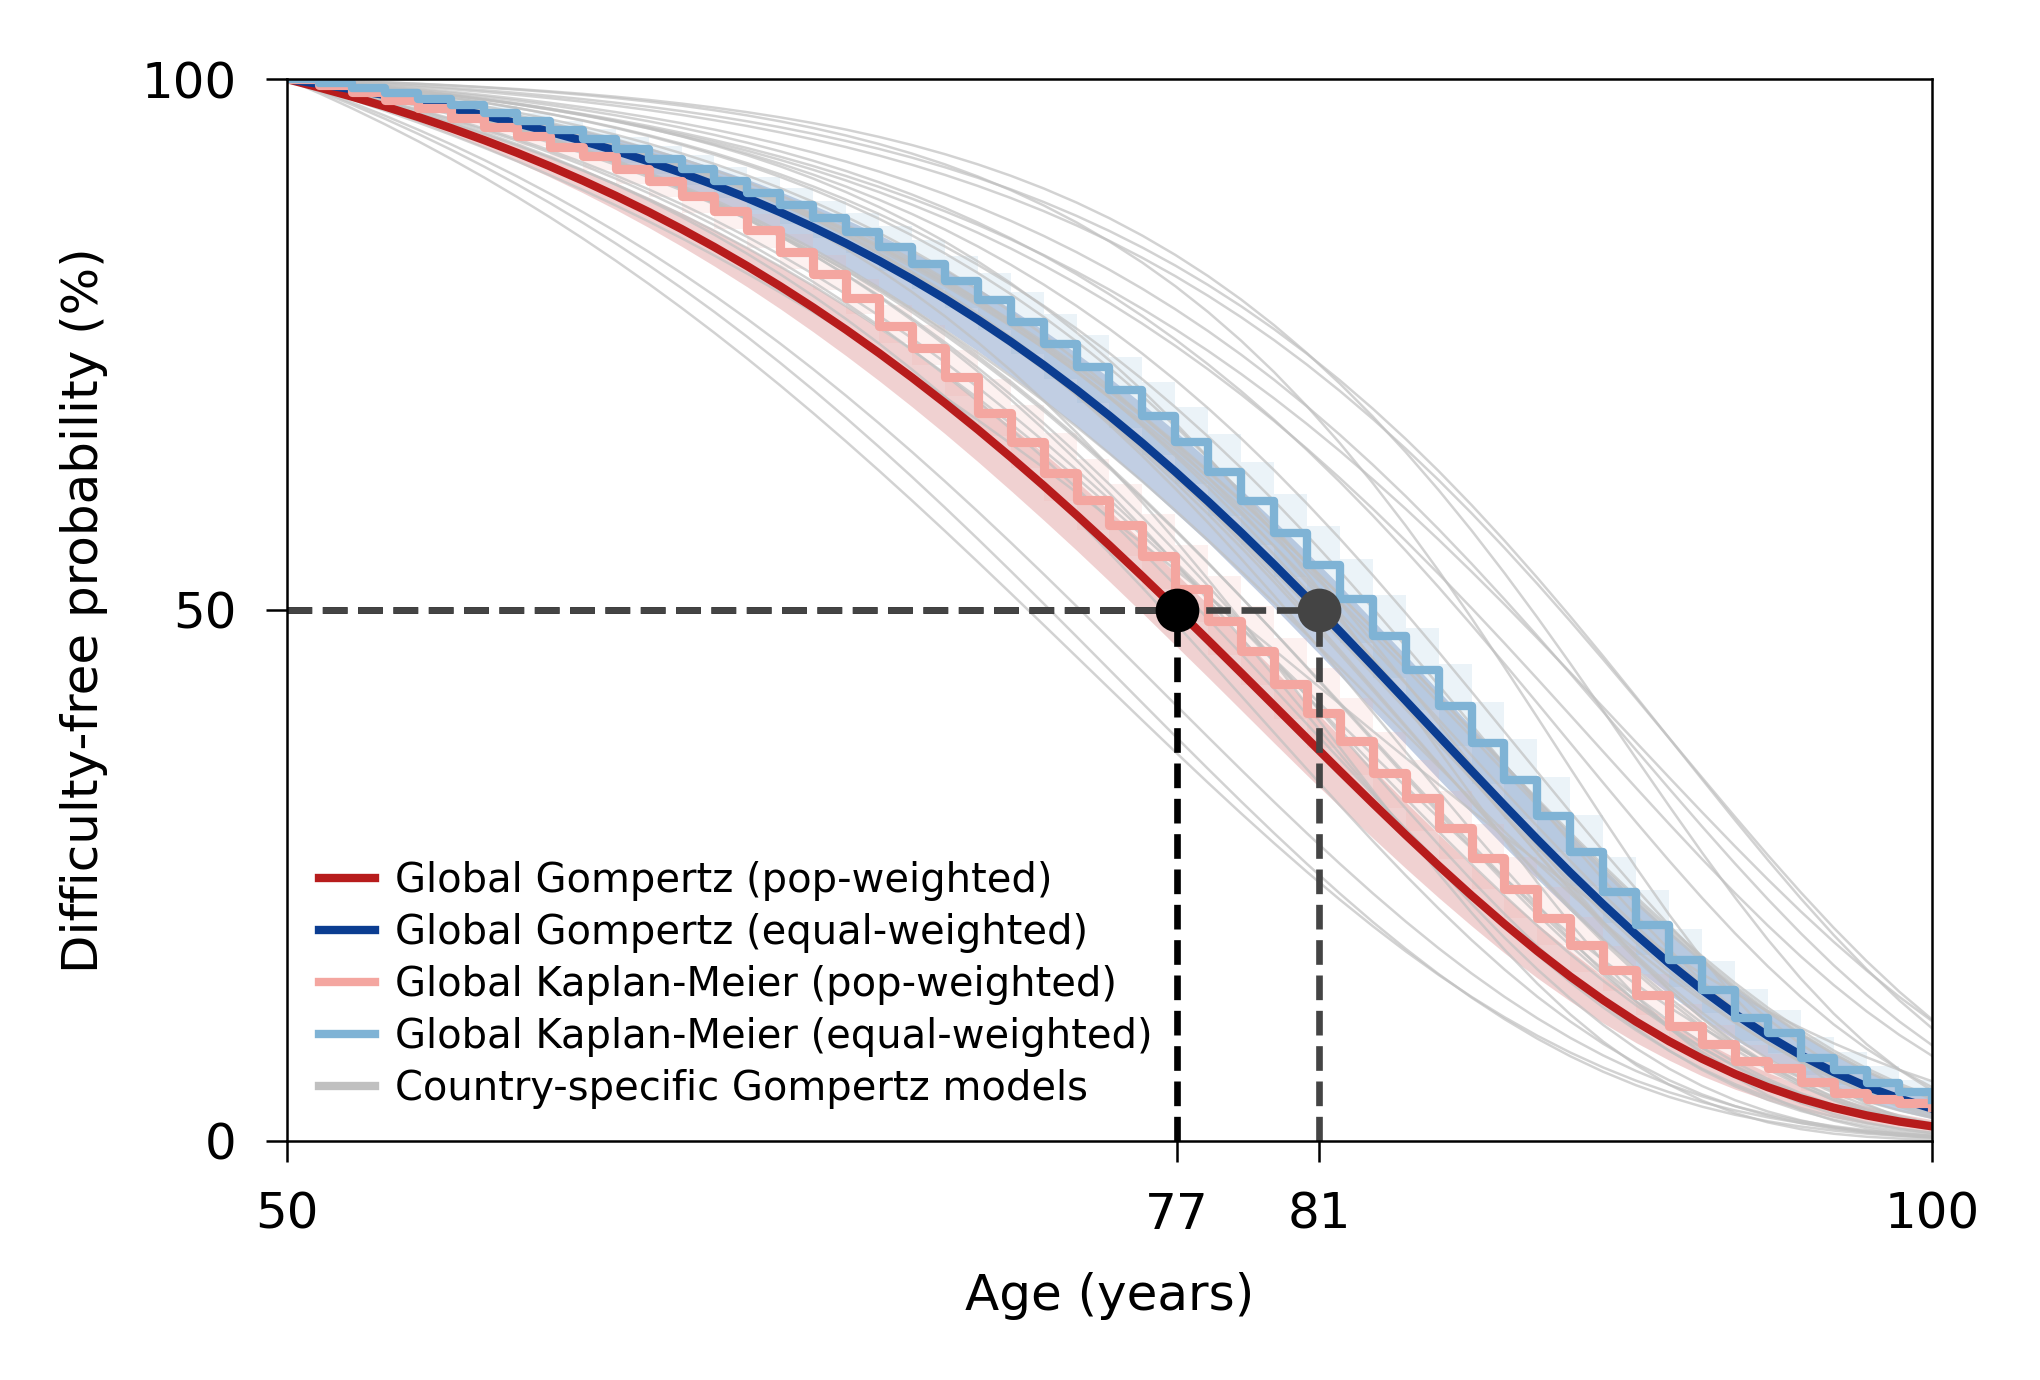

All-countries survival plot saved.


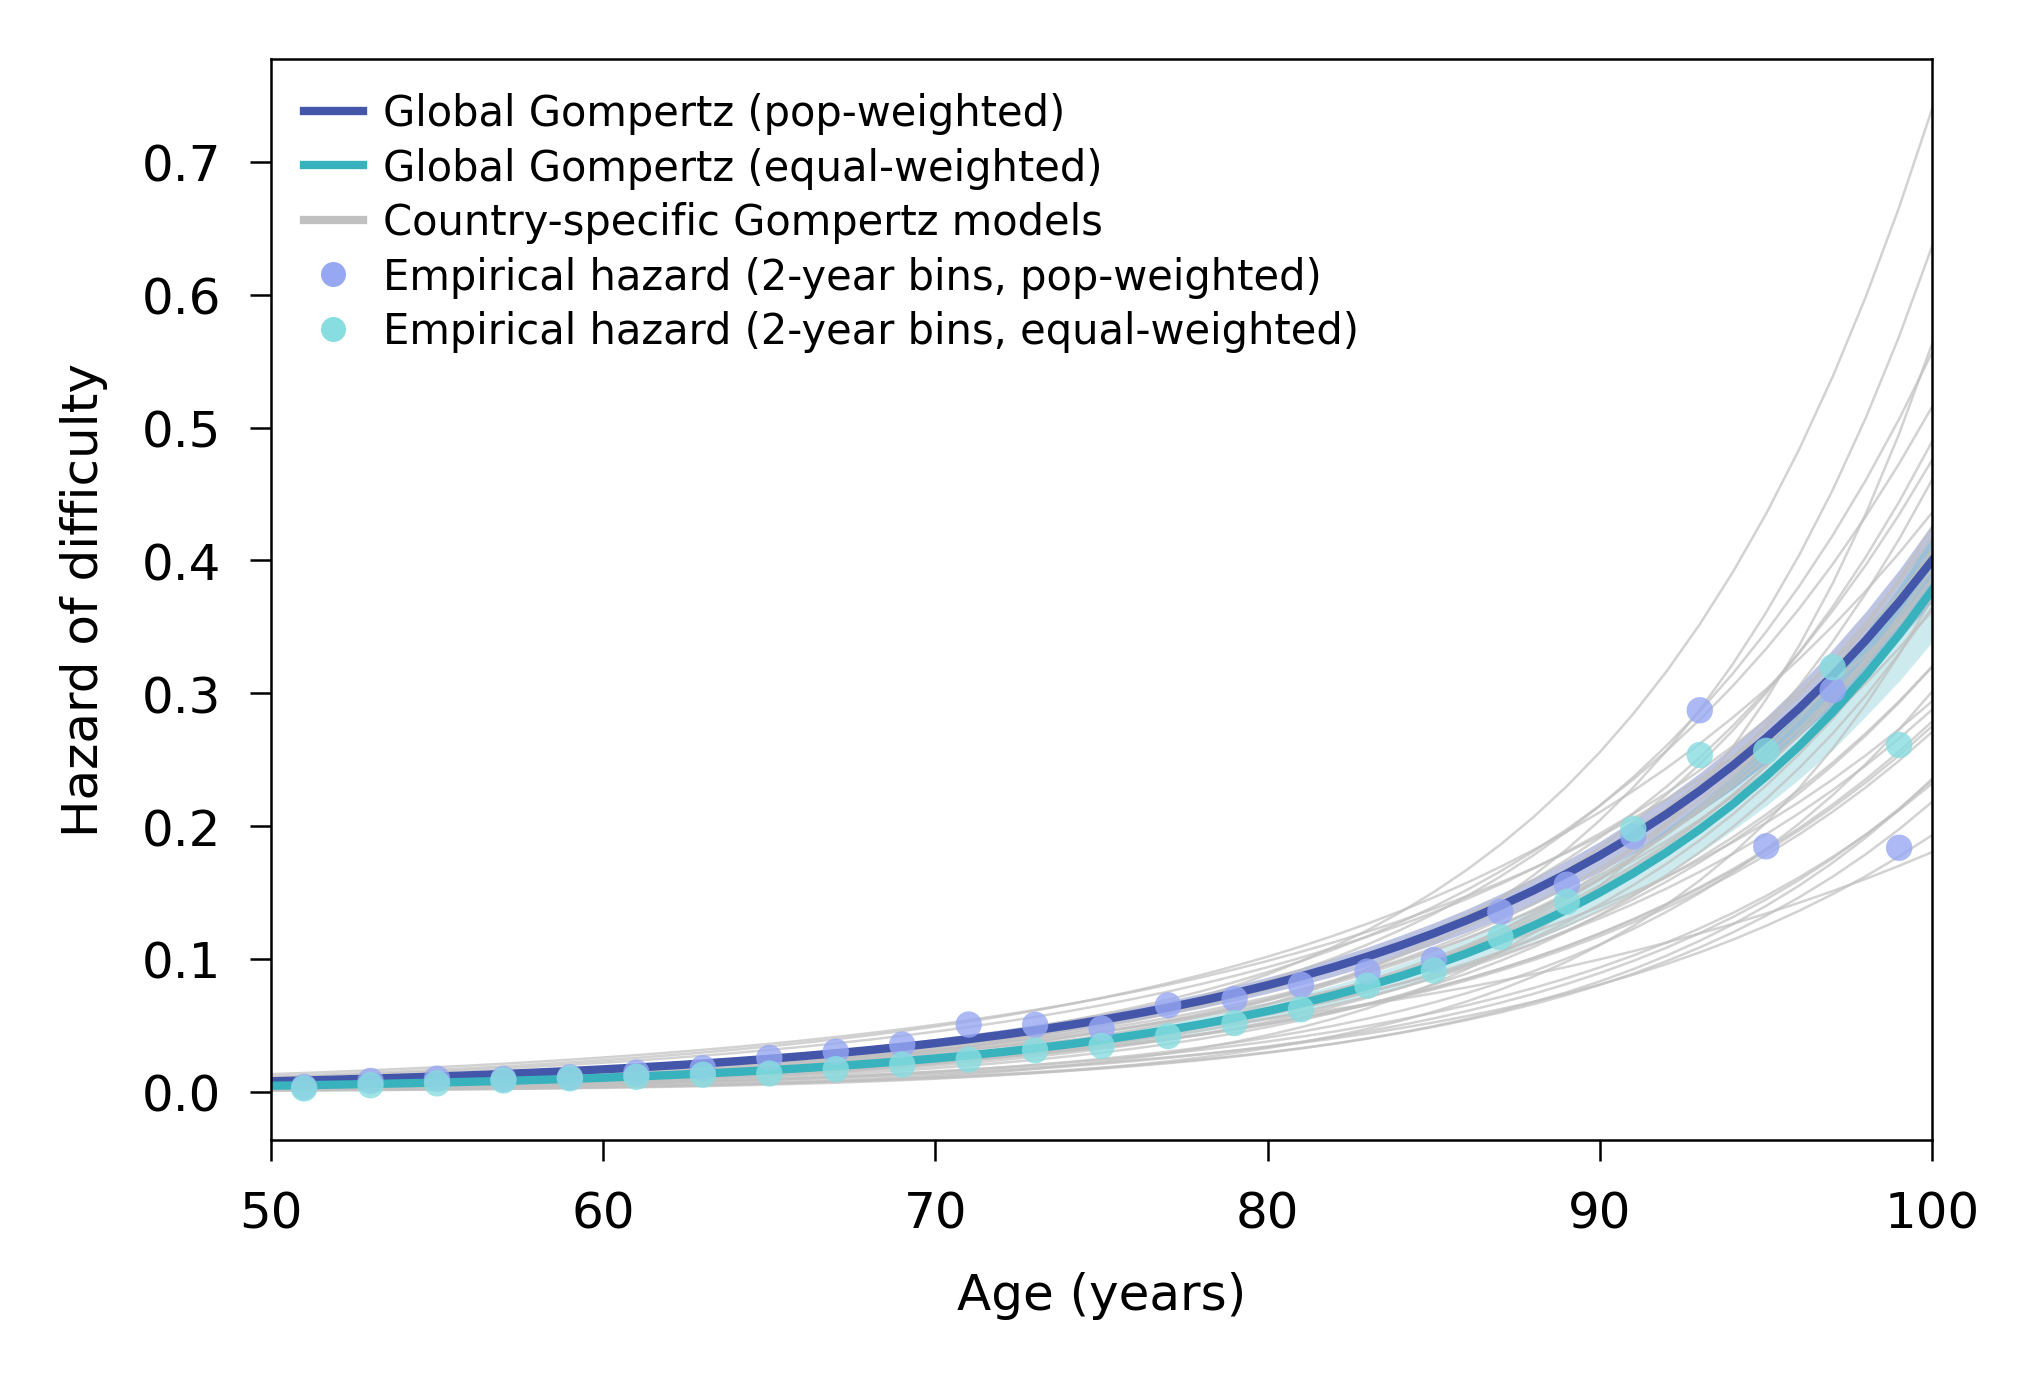

All-countries hazard plot saved.


In [30]:
# (13) Global population-weighted + equal-weighted curves + bootstrap CI (tables) + combined plots
ok_res = [r for r in results if r.ok]

def _load_population_weights(countries: List[str]) -> Tuple[Dict[str, float], pd.DataFrame]:
    iso_path = os.path.join(os.path.dirname(DATA_PATH), "iso40.csv")
    pop_path = os.path.join(os.path.dirname(DATA_PATH), "wb/wb_2019_2024.csv")
    if not os.path.exists(iso_path):
        print("Missing iso40.csv:", iso_path)
        return {}, pd.DataFrame()
    if not os.path.exists(pop_path):
        print("Missing wb_2019_2024.csv:", pop_path)
        return {}, pd.DataFrame()

    iso = pd.read_csv(iso_path)
    iso["isocountry_c"] = iso["isocountry_c"].astype(str).str.strip().str.lower()
    iso["iso3c"] = iso["iso3c"].astype(str).str.strip().str.upper()
    iso_map = dict(zip(iso["isocountry_c"], iso["iso3c"]))

    pop = pd.read_csv(pop_path)
    pop["iso3"] = pop["iso3"].astype(str).str.strip().str.upper()
    pop["date"] = pd.to_numeric(pop["date"], errors="coerce")
    pop = pop.dropna(subset=["iso3", "date", "total_population"])
    pop_latest = pop.sort_values("date").groupby("iso3", as_index=False).tail(1)
    pop_latest = pop_latest.rename(columns={"date": "year", "total_population": "population"})

    rows = []
    missing = []
    for c in countries:
        key = str(c).strip().lower()
        iso3 = iso_map.get(key, "")
        if not iso3:
            missing.append(c)
            continue
        pop_row = pop_latest.loc[pop_latest["iso3"] == iso3]
        if pop_row.empty:
            missing.append(c)
            continue
        population = float(pop_row.iloc[0]["population"])
        year = int(pop_row.iloc[0]["year"])
        rows.append({"country": c, "iso3": iso3, "year": year, "population": population})

    if missing:
        print("Missing population for:", missing)
    if not rows:
        return {}, pd.DataFrame()
    pop_df = pd.DataFrame(rows)
    total_pop = pop_df["population"].sum()
    pop_df["weight"] = pop_df["population"] / total_pop
    weight_map = {r["country"]: r["weight"] for _, r in pop_df.iterrows()}
    return weight_map, pop_df

def _km_surv_weighted(person_df: pd.DataFrame, country_weights: Dict[str, float]) -> pd.DataFrame:
    if person_df is None or person_df.empty or not country_weights:
        return pd.DataFrame(columns=["age", "surv"])
    df = person_df.copy()
    df = df.dropna(subset=["country", "entry_age", "exit_age", "event_w"])
    df["country"] = df["country"].astype(str)
    df = df.loc[df["country"].isin(country_weights.keys())]
    if df.empty:
        return pd.DataFrame(columns=["age", "surv"])
    counts = df["country"].value_counts().to_dict()
    df["w"] = df["country"].map(lambda c: country_weights.get(c, np.nan) / counts.get(c, 1))
    df = df.dropna(subset=["w"])
    entry = df["entry_age"].to_numpy(dtype=float)
    exit_ = df["exit_age"].to_numpy(dtype=float)
    event = df["event_w"].to_numpy(dtype=int)
    weights = df["w"].to_numpy(dtype=float)
    event_times = np.sort(np.unique(exit_[event == 1]))
    if event_times.size == 0:
        return pd.DataFrame(columns=["age", "surv"])
    ages = []
    surv_vals = []
    s = 1.0
    for t in event_times:
        at_risk = (entry <= t) & (exit_ >= t)
        n_w = float(weights[at_risk].sum())
        d_w = float(weights[(event == 1) & (exit_ == t)].sum())
        if n_w <= 0 or d_w <= 0:
            continue
        s *= (1.0 - d_w / n_w)
        ages.append(t)
        surv_vals.append(s)
    if len(ages) == 0:
        return pd.DataFrame(columns=["age", "surv"])
    km_df = pd.DataFrame({"age": ages, "surv": surv_vals})
    start_row = pd.DataFrame({"age": [START_AGE], "surv": [1.0]})
    km_df = pd.concat([start_row, km_df], ignore_index=True)
    return km_df

def _km_curve_weighted_bootstrap(person_df: pd.DataFrame, country_weights: Dict[str, float], B: int = 300, seed: int = 1) -> pd.DataFrame:
    est_df = _km_surv_weighted(person_df, country_weights)
    if est_df.empty:
        return pd.DataFrame(columns=["age", "surv", "lower", "upper"])
    countries = [str(c) for c in country_weights.keys()]
    if len(countries) == 0:
        return pd.DataFrame(columns=["age", "surv", "lower", "upper"])
    p = np.array([float(country_weights[c]) for c in countries], dtype=float)
    p = p / p.sum() if p.sum() > 0 else np.ones(len(countries), dtype=float) / len(countries)
    est_ages = est_df["age"].to_numpy(dtype=float)

    def _step_eval(curve_df: pd.DataFrame, ages_target: np.ndarray) -> np.ndarray:
        if curve_df is None or curve_df.empty:
            return np.full(len(ages_target), np.nan)
        x = curve_df["age"].to_numpy(dtype=float)
        y = curve_df["surv"].to_numpy(dtype=float)
        idx = np.searchsorted(x, ages_target, side="right") - 1
        out = np.ones(len(ages_target), dtype=float)
        valid = idx >= 0
        out[valid] = y[idx[valid]]
        return out

    rng = np.random.default_rng(seed)
    boot = np.full((B, len(est_ages)), np.nan)
    n_cty = len(countries)
    for b in range(B):
        draw_idx = rng.choice(np.arange(n_cty), size=n_cty, replace=True, p=p)
        cnt = np.bincount(draw_idx, minlength=n_cty).astype(float)
        if cnt.sum() <= 0:
            continue
        w_boot = cnt / cnt.sum()
        boot_map = {countries[i]: float(w_boot[i]) for i in range(n_cty) if w_boot[i] > 0}
        b_df = _km_surv_weighted(person_df, boot_map)
        boot[b] = _step_eval(b_df, est_ages)

    lower = np.nanpercentile(boot, 2.5, axis=0)
    upper = np.nanpercentile(boot, 97.5, axis=0)
    out = est_df.copy()
    out["lower"] = lower
    out["upper"] = upper
    return out

if len(ok_res) < 2:
    print("Too few countries with successful fits to make a global curve.")
else:
    pop_weight_map, pop_report = _load_population_weights([r.country for r in ok_res])
    if pop_report is not None and not pop_report.empty:
        pop_report = pop_report.sort_values("weight", ascending=False)
        print("Population weights (latest available year):")
        print(pop_report.to_string(index=False, formatters={
            "population": lambda x: f"{x:,.0f}",
            "weight": lambda x: f"{x:.2%}",
        }))
        print(f"Total population: {pop_report['population'].sum():,.0f}")

    countries_eq = sorted({r.country for r in ok_res})
    eq_weight_map = {c: 1.0 / len(countries_eq) for c in countries_eq} if countries_eq else {}
    if pop_weight_map:
        ok_res_w = [r for r in ok_res if r.country in pop_weight_map]
        if len(ok_res_w) < len(ok_res):
            print(f"Using {len(ok_res_w)} countries with population weights out of {len(ok_res)}.")
    else:
        ok_res_w = ok_res
    countries_w = sorted({r.country for r in ok_res_w})

    def build_mat(component: str, value_col: str, res_list: List[CountryResult]):
        df = pd.concat([getattr(r, component) for r in res_list], ignore_index=True)
        ages = np.sort(df["age"].unique())
        wide = df.pivot(index="age", columns="country", values=value_col).reindex(ages)
        return wide.to_numpy(), ages, wide.columns.tolist()

    def _weighted_mean(mat: np.ndarray, weights: np.ndarray) -> np.ndarray:
        w = np.asarray(weights, dtype=float)
        w = w / w.sum() if w.sum() > 0 else np.ones_like(w) / len(w)
        valid = np.isfinite(mat)
        out = np.zeros(mat.shape[0])
        for i in range(mat.shape[0]):
            mask = valid[i]
            if not mask.any():
                out[i] = np.nan
                continue
            w_i = w[mask]
            if w_i.sum() <= 0:
                out[i] = np.nan
            else:
                out[i] = np.nansum(mat[i, mask] * w_i) / w_i.sum()
        return out

    def boot_ci_over_countries_weighted(mat: np.ndarray, weights: np.ndarray, B: int = 1000, seed: int = 1):
        rng = np.random.default_rng(seed)
        n_cty = mat.shape[1]
        w = np.asarray(weights, dtype=float)
        w = w / w.sum() if w.sum() > 0 else np.ones_like(w) / len(w)
        est = _weighted_mean(mat, w)
        boot = np.zeros((B, mat.shape[0]))
        for b in range(B):
            idx = rng.choice(np.arange(n_cty), size=n_cty, replace=True, p=w)
            boot[b] = np.nanmean(mat[:, idx], axis=1)
        return est, np.nanpercentile(boot, 2.5, axis=0), np.nanpercentile(boot, 97.5, axis=0)

    B_BOOT = 1000
    SEED0  = 10000000

    # Weighted global curves
    surv_mat_w, ages_w, surv_cols_w = build_mat("pred", "surv", ok_res_w)
    surv_w = np.array([pop_weight_map.get(c, np.nan) for c in surv_cols_w], dtype=float)
    if not np.all(np.isfinite(surv_w)):
        surv_w = np.ones(len(surv_cols_w), dtype=float)
    surv_est_w, surv_lcl_w, surv_ucl_w = boot_ci_over_countries_weighted(surv_mat_w, surv_w, B=B_BOOT, seed=SEED0)
    global_surv_w = pd.DataFrame({"age": ages_w, "est": surv_est_w, "lower": surv_lcl_w, "upper": surv_ucl_w})

    haz_mat_w, ages_w, haz_cols_w = build_mat("haz", "hazard", ok_res_w)
    haz_w = np.array([pop_weight_map.get(c, np.nan) for c in haz_cols_w], dtype=float)
    if not np.all(np.isfinite(haz_w)):
        haz_w = np.ones(len(haz_cols_w), dtype=float)
    haz_est_w, haz_lcl_w, haz_ucl_w = boot_ci_over_countries_weighted(haz_mat_w, haz_w, B=B_BOOT, seed=SEED0 + 1)
    global_haz_w = pd.DataFrame({"age": ages_w, "est": haz_est_w, "lower": haz_lcl_w, "upper": haz_ucl_w})

    chz_mat_w, ages_w, chz_cols_w = build_mat("cumhaz", "cumhaz", ok_res_w)
    chz_w = np.array([pop_weight_map.get(c, np.nan) for c in chz_cols_w], dtype=float)
    if not np.all(np.isfinite(chz_w)):
        chz_w = np.ones(len(chz_cols_w), dtype=float)
    chz_est_w, chz_lcl_w, chz_ucl_w = boot_ci_over_countries_weighted(chz_mat_w, chz_w, B=B_BOOT, seed=SEED0 + 2)
    global_cumhaz_w = pd.DataFrame({"age": ages_w, "est": chz_est_w, "lower": chz_lcl_w, "upper": chz_ucl_w})

    cdf_mat_w, ages_w, cdf_cols_w = build_mat("cdf", "cdf", ok_res_w)
    cdf_w = np.array([pop_weight_map.get(c, np.nan) for c in cdf_cols_w], dtype=float)
    if not np.all(np.isfinite(cdf_w)):
        cdf_w = np.ones(len(cdf_cols_w), dtype=float)
    cdf_est_w, cdf_lcl_w, cdf_ucl_w = boot_ci_over_countries_weighted(cdf_mat_w, cdf_w, B=B_BOOT, seed=SEED0 + 3)
    global_cdf_w = pd.DataFrame({"age": ages_w, "est": cdf_est_w, "lower": cdf_lcl_w, "upper": cdf_ucl_w})

    # Equal-weighted global curves
    surv_mat_eq, ages_eq, surv_cols_eq = build_mat("pred", "surv", ok_res)
    surv_w_eq = np.ones(len(surv_cols_eq), dtype=float)
    surv_est_eq, surv_lcl_eq, surv_ucl_eq = boot_ci_over_countries_weighted(surv_mat_eq, surv_w_eq, B=B_BOOT, seed=SEED0 + 10)
    global_surv_eq = pd.DataFrame({"age": ages_eq, "est": surv_est_eq, "lower": surv_lcl_eq, "upper": surv_ucl_eq})

    haz_mat_eq, ages_eq, haz_cols_eq = build_mat("haz", "hazard", ok_res)
    haz_w_eq = np.ones(len(haz_cols_eq), dtype=float)
    haz_est_eq, haz_lcl_eq, haz_ucl_eq = boot_ci_over_countries_weighted(haz_mat_eq, haz_w_eq, B=B_BOOT, seed=SEED0 + 11)
    global_haz_eq = pd.DataFrame({"age": ages_eq, "est": haz_est_eq, "lower": haz_lcl_eq, "upper": haz_ucl_eq})

    chz_mat_eq, ages_eq, chz_cols_eq = build_mat("cumhaz", "cumhaz", ok_res)
    chz_w_eq = np.ones(len(chz_cols_eq), dtype=float)
    chz_est_eq, chz_lcl_eq, chz_ucl_eq = boot_ci_over_countries_weighted(chz_mat_eq, chz_w_eq, B=B_BOOT, seed=SEED0 + 12)
    global_cumhaz_eq = pd.DataFrame({"age": ages_eq, "est": chz_est_eq, "lower": chz_lcl_eq, "upper": chz_ucl_eq})

    cdf_mat_eq, ages_eq, cdf_cols_eq = build_mat("cdf", "cdf", ok_res)
    cdf_w_eq = np.ones(len(cdf_cols_eq), dtype=float)
    cdf_est_eq, cdf_lcl_eq, cdf_ucl_eq = boot_ci_over_countries_weighted(cdf_mat_eq, cdf_w_eq, B=B_BOOT, seed=SEED0 + 13)
    global_cdf_eq = pd.DataFrame({"age": ages_eq, "est": cdf_est_eq, "lower": cdf_lcl_eq, "upper": cdf_ucl_eq})

    global_surv_eq.to_csv(os.path.join(TAB_DIR, "global_equalweight_survival_curve.csv"), index=False)
    global_haz_eq.to_csv(os.path.join(TAB_DIR, "global_equalweight_hazard_curve.csv"), index=False)
    global_cumhaz_eq.to_csv(os.path.join(TAB_DIR, "global_equalweight_cumhaz_curve.csv"), index=False)
    global_cdf_eq.to_csv(os.path.join(TAB_DIR, "global_equalweight_cdf_curve.csv"), index=False)

    global_surv_w.to_csv(os.path.join(TAB_DIR, "global_popweight_survival_curve.csv"), index=False)
    global_haz_w.to_csv(os.path.join(TAB_DIR, "global_popweight_hazard_curve.csv"), index=False)
    global_cumhaz_w.to_csv(os.path.join(TAB_DIR, "global_popweight_cumhaz_curve.csv"), index=False)
    global_cdf_w.to_csv(os.path.join(TAB_DIR, "global_popweight_cdf_curve.csv"), index=False)

    print("Global tables saved to:", TAB_DIR)

    def _interp_at_age(df: pd.DataFrame, col: str, age: float) -> float:
        if df.empty:
            return np.nan
        x = df["age"].to_numpy(dtype=float)
        y = df[col].to_numpy(dtype=float)
        return float(np.interp(age, x, y))

    def _global_metrics_from_curves(global_surv_df: pd.DataFrame, global_haz_df: pd.DataFrame, met_source: pd.DataFrame) -> pd.DataFrame:
        if global_surv_df.empty:
            return pd.DataFrame()
        age_vals = global_surv_df["age"].to_numpy(dtype=float)
        surv_vals = np.clip(global_surv_df["est"].to_numpy(dtype=float), 0, 1)
        rmst_years = START_AGE + trapz(age_vals, surv_vals)
        rmst_lcl = START_AGE + trapz(
            age_vals,
            np.clip(global_surv_df["lower"].to_numpy(dtype=float), 0, 1),
        )
        rmst_ucl = START_AGE + trapz(
            age_vals,
            np.clip(global_surv_df["upper"].to_numpy(dtype=float), 0, 1),
        )
        q10_age = find_quantile_age(age_vals, surv_vals, p_surv=0.10)
        q25_age = find_quantile_age(age_vals, surv_vals, p_surv=0.75)
        q50_age = find_quantile_age(age_vals, surv_vals, p_surv=0.50)
        q75_age = find_quantile_age(age_vals, surv_vals, p_surv=0.25)
        iqr_survival = q75_age - q25_age
        high_width = q10_age - q50_age

        total_n = int(met_source["n"].sum()) if met_source is not None and not met_source.empty else 0
        total_events = int(met_source["events"].sum()) if met_source is not None and not met_source.empty else 0

        metrics = {
            "country": "Global",
            "continent": "Global",
            "n": total_n,
            "events": total_events,
            "rmst": rmst_years,
            "rmst_lcl": rmst_lcl,
            "rmst_ucl": rmst_ucl,
            "t50": q50_age,
            "t_at_S_0_75": q25_age,
            "t_at_S_0_25": q75_age,
            "iqr_survival": iqr_survival,
            "high_width": high_width,
        }
        for age in REPORT_AGES:
            metrics[f"surv_at_{age}"] = _interp_at_age(global_surv_df, "est", age)
            metrics[f"haz_at_{age}"] = _interp_at_age(global_haz_df, "est", age)
        return pd.DataFrame([metrics])

    def _boot_mean_ci(values: np.ndarray, weights: np.ndarray, B: int = 1000, seed: int = 1):
        values = np.asarray(values, dtype=float)
        weights = np.asarray(weights, dtype=float)
        mask = np.isfinite(values) & np.isfinite(weights)
        values = values[mask]
        weights = weights[mask]
        if values.size == 0:
            return np.nan, np.nan, np.nan, np.nan
        w = weights / weights.sum() if weights.sum() > 0 else np.ones_like(weights) / len(weights)
        est = float(np.sum(values * w))
        rng = np.random.default_rng(seed)
        n = values.size
        boot = np.zeros(B)
        for b in range(B):
            idx = rng.choice(np.arange(n), size=n, replace=True, p=w)
            boot[b] = np.mean(values[idx])
        lcl, ucl = np.nanpercentile(boot, [2.5, 97.5])
        se = float(np.nanstd(boot, ddof=1))
        return est, se, float(lcl), float(ucl)

    # Global metrics (equal-weighted and population-weighted)
    met_source_eq = pd.concat([r.metrics for r in ok_res if r.metrics is not None], ignore_index=True)
    met_source_w = pd.concat([r.metrics for r in ok_res_w if r.metrics is not None], ignore_index=True)
    global_metrics_df_eq = _global_metrics_from_curves(global_surv_eq, global_haz_eq, met_source_eq)
    global_metrics_df_w = _global_metrics_from_curves(global_surv_w, global_haz_w, met_source_w)
    metrics_path_eq = os.path.join(TAB_DIR, "global_equalweight_metrics.csv")
    metrics_path_w = os.path.join(TAB_DIR, "global_popweight_metrics.csv")
    if not global_metrics_df_eq.empty:
        global_metrics_df_eq.to_csv(metrics_path_eq, index=False)
        print("Saved:", metrics_path_eq)
    if not global_metrics_df_w.empty:
        global_metrics_df_w.to_csv(metrics_path_w, index=False)
        print("Saved:", metrics_path_w)

    # Global params (equal-weighted and population-weighted)
    if "pars_all" in globals() and pars_all is not None and not pars_all.empty:
        param_source_eq = pars_all.copy()
    else:
        param_source_eq = pd.concat([r.pars for r in ok_res if r.pars is not None], ignore_index=True)
    param_source_eq = param_source_eq.dropna(subset=["gamma_est", "lambda_est", "country"])

    if "pars_all" in globals() and pars_all is not None and not pars_all.empty:
        param_source_w = pars_all.copy()
    else:
        param_source_w = pd.concat([r.pars for r in ok_res_w if r.pars is not None], ignore_index=True)
    if pop_weight_map:
        param_source_w = param_source_w.loc[param_source_w["country"].isin(pop_weight_map.keys())].copy()
    param_source_w = param_source_w.dropna(subset=["gamma_est", "lambda_est", "country"])

    global_params_df_eq = pd.DataFrame()
    if not param_source_eq.empty:
        weight_vals_eq = np.ones(len(param_source_eq), dtype=float)
        gamma_est_eq, gamma_se_eq, gamma_l_eq, gamma_u_eq = _boot_mean_ci(
            param_source_eq["gamma_est"].to_numpy(dtype=float), weight_vals_eq, B=B_BOOT, seed=SEED0 + 20
        )
        lambda_est_eq, lambda_se_eq, lambda_l_eq, lambda_u_eq = _boot_mean_ci(
            param_source_eq["lambda_est"].to_numpy(dtype=float), weight_vals_eq, B=B_BOOT, seed=SEED0 + 21
        )
        n_countries_eq = int(param_source_eq["country"].nunique()) if "country" in param_source_eq.columns else int(len(param_source_eq))
        global_params_df_eq = pd.DataFrame([{
            "country": "Global",
            "continent": "Global",
            "gamma_est": gamma_est_eq,
            "gamma_se": gamma_se_eq,
            "gamma_l": gamma_l_eq,
            "gamma_u": gamma_u_eq,
            "lambda_est": lambda_est_eq,
            "lambda_se": lambda_se_eq,
            "lambda_l": lambda_l_eq,
            "lambda_u": lambda_u_eq,
            "n_countries": n_countries_eq,
        }])

    global_params_df_w = pd.DataFrame()
    if not param_source_w.empty:
        if pop_weight_map:
            weight_vals_w = param_source_w["country"].map(pop_weight_map).to_numpy(dtype=float)
        else:
            weight_vals_w = np.ones(len(param_source_w), dtype=float)
        gamma_est_w, gamma_se_w, gamma_l_w, gamma_u_w = _boot_mean_ci(
            param_source_w["gamma_est"].to_numpy(dtype=float), weight_vals_w, B=B_BOOT, seed=SEED0 + 22
        )
        lambda_est_w, lambda_se_w, lambda_l_w, lambda_u_w = _boot_mean_ci(
            param_source_w["lambda_est"].to_numpy(dtype=float), weight_vals_w, B=B_BOOT, seed=SEED0 + 23
        )
        n_countries_w = int(param_source_w["country"].nunique()) if "country" in param_source_w.columns else int(len(param_source_w))
        global_params_df_w = pd.DataFrame([{
            "country": "Global",
            "continent": "Global",
            "gamma_est": gamma_est_w,
            "gamma_se": gamma_se_w,
            "gamma_l": gamma_l_w,
            "gamma_u": gamma_u_w,
            "lambda_est": lambda_est_w,
            "lambda_se": lambda_se_w,
            "lambda_l": lambda_l_w,
            "lambda_u": lambda_u_w,
            "n_countries": n_countries_w,
        }])

    params_path_eq = os.path.join(TAB_DIR, "global_equalweight_params.csv")
    params_path_w = os.path.join(TAB_DIR, "global_popweight_params.csv")
    if not global_params_df_eq.empty:
        global_params_df_eq.to_csv(params_path_eq, index=False)
        print("Saved:", params_path_eq)
    if not global_params_df_w.empty:
        global_params_df_w.to_csv(params_path_w, index=False)
        print("Saved:", params_path_w)

    # KM curves (equal-weighted and population-weighted)
    km_w = _km_curve_weighted_bootstrap(person, pop_weight_map, B=300, seed=SEED0 + 30) if pop_weight_map else pd.DataFrame()
    km_eq = _km_curve_weighted_bootstrap(person, eq_weight_map, B=300, seed=SEED0 + 31) if eq_weight_map else pd.DataFrame()

    def _empirical_hazard_weighted_global(person_df: pd.DataFrame, country_weights: Dict[str, float], bin_width: int = 2) -> pd.DataFrame:
        if person_df is None or person_df.empty or not country_weights:
            return pd.DataFrame(columns=["age", "haz_emp"])
        emp_df = person_df.dropna(subset=["country", "entry_age", "exit_age", "event_w"]).copy()
        emp_df["country"] = emp_df["country"].astype(str)
        emp_df = emp_df.loc[emp_df["country"].isin(country_weights.keys())]
        if emp_df.empty:
            return pd.DataFrame(columns=["age", "haz_emp"])
        counts = emp_df["country"].value_counts().to_dict()
        emp_df["w"] = emp_df["country"].map(lambda c: country_weights.get(c, np.nan) / counts.get(c, 1))
        emp_df = emp_df.dropna(subset=["w"])
        bins = np.arange(START_AGE, AGE_MAX + bin_width, bin_width)
        emp_rows = []
        entry_arr = emp_df["entry_age"].to_numpy(dtype=float)
        exit_arr = emp_df["exit_age"].to_numpy(dtype=float)
        event_arr = emp_df["event_w"].to_numpy(dtype=int)
        w_arr = emp_df["w"].to_numpy(dtype=float)
        for b0 in bins[:-1]:
            b1 = b0 + bin_width
            time_in_bin = np.maximum(0.0, np.minimum(exit_arr, b1) - np.maximum(entry_arr, b0))
            person_time = float(np.sum(time_in_bin * w_arr))
            events = float(np.sum(w_arr[(event_arr == 1) & (exit_arr >= b0) & (exit_arr < b1)]))
            if person_time <= 0 or events <= 0:
                continue
            emp_rows.append({"age": (b0 + b1) / 2.0, "haz_emp": events / person_time})
        return pd.DataFrame(emp_rows)

    global_emp_pop = _empirical_hazard_weighted_global(person, pop_weight_map, bin_width=2) if pop_weight_map else pd.DataFrame()
    global_emp_eq = _empirical_hazard_weighted_global(person, eq_weight_map, bin_width=2) if eq_weight_map else pd.DataFrame()

    # Plot all countries survival & hazard curves in one figure
    from matplotlib.lines import Line2D

    COL_GOMPTZ_W = "#B71C1C"
    COL_GOMPTZ_EQ = "#0B3D91"
    COL_KM_W = "#F4A6A0"
    COL_KM_EQ = "#7FB3D5"

    # Survival curves
    fig, ax = plt.subplots(figsize=(3.5, 2.4), dpi=600)

    for r in results:
        if not r.ok:
            continue
        df = r.pred
        ax.plot(df["age"], df["surv"], linewidth=0.3, alpha=0.7, color="silver")

    # Global Gompertz (population-weighted + equal-weighted)
    ax.fill_between(global_surv_w["age"], global_surv_w["lower"], global_surv_w["upper"], color=COL_GOMPTZ_W, alpha=0.20, linewidth=0)
    ax.plot(global_surv_w["age"], global_surv_w["est"], color=COL_GOMPTZ_W, linewidth=1)
    ax.fill_between(global_surv_eq["age"], global_surv_eq["lower"], global_surv_eq["upper"], color=COL_GOMPTZ_EQ, alpha=0.25, linewidth=0)
    ax.plot(global_surv_eq["age"], global_surv_eq["est"], color=COL_GOMPTZ_EQ, linewidth=1)

    # Global KM (population-weighted + equal-weighted)
    if not km_w.empty:
        ax.fill_between(km_w["age"], km_w["lower"], km_w["upper"], step="post", color=COL_KM_W, alpha=0.15, linewidth=0)
        ax.step(km_w["age"], km_w["surv"], where="post", color=COL_KM_W, linewidth=1.1)
    if not km_eq.empty:
        ax.fill_between(km_eq["age"], km_eq["lower"], km_eq["upper"], step="post", color=COL_KM_EQ, alpha=0.15, linewidth=0)
        ax.step(km_eq["age"], km_eq["surv"], where="post", color=COL_KM_EQ, linewidth=1.0)

    q50_age = find_quantile_age(global_surv_w["age"].values, global_surv_w["est"].values, p_surv=0.5)
    q50_age_eq = find_quantile_age(global_surv_eq["age"].values, global_surv_eq["est"].values, p_surv=0.5)
    if np.isfinite(q50_age):
        ax.scatter([q50_age], [0.5], s=18, color="black", zorder=5)
        ax.vlines(q50_age, ymin=0, ymax=0.5, linestyles="--", colors="black", linewidth=0.8)
        ax.hlines(0.5, xmin=START_AGE, xmax=q50_age, linestyles="--", colors="black", linewidth=0.8)
    if np.isfinite(q50_age_eq):
        ax.scatter([q50_age_eq], [0.5], s=18, color="#444444", zorder=5)
        ax.vlines(q50_age_eq, ymin=0, ymax=0.5, linestyles="--", colors="#444444", linewidth=0.8)
        ax.hlines(0.5, xmin=START_AGE, xmax=q50_age_eq, linestyles="--", colors="#444444", linewidth=0.8)

    ax.set_xlim(START_AGE, AGE_MAX); ax.set_ylim(0, 1)
    ax.set_xlabel("Age (years)", fontsize=6)
    ax.set_ylabel("Difficulty-free probability (%)", fontsize=6)
    ax.set_yticks([0, 0.5, 1]); ax.set_yticklabels(["0", "50", "100"])
    ax.tick_params(axis="both", labelsize=6, width=0.3)
    xticks = [START_AGE, AGE_MAX]
    if np.isfinite(q50_age):
        if all(abs(q50_age - t) > 1e-6 for t in xticks):
            xticks.append(q50_age)
    if np.isfinite(q50_age_eq):
        if all(abs(q50_age_eq - t) > 1e-6 for t in xticks):
            xticks.append(q50_age_eq)
    xticks = sorted(xticks)
    ax.set_xticks(xticks)
    if np.isfinite(q50_age) or np.isfinite(q50_age_eq):
        xtick_labels = []
        for t in xticks:
            xtick_labels.append(f"{int(round(t))}")
        ax.set_xticklabels(xtick_labels)

    legend_handles = [
        Line2D([0], [0], color=COL_GOMPTZ_W, lw=1, label="Global Gompertz (pop-weighted)"),
        Line2D([0], [0], color=COL_GOMPTZ_EQ, lw=1, label="Global Gompertz (equal-weighted)"),
        Line2D([0], [0], color=COL_KM_W, lw=1, label="Global Kaplan-Meier (pop-weighted)"),
        Line2D([0], [0], color=COL_KM_EQ, lw=1, label="Global Kaplan-Meier (equal-weighted)"),
        Line2D([0], [0], color="silver", lw=1, label="Country-specific Gompertz models"),
    ]
    ax.legend(
        handles=legend_handles, loc="lower left", frameon=False, fontsize=4.8,
        handlelength=1.4, handletextpad=0.5, labelspacing=0.3, borderpad=0.3
     )

    theme_std(ax, font_size=6)
    for spine in ax.spines.values():
        spine.set_linewidth(0.3)
    ax.tick_params(axis="both", labelsize=6, width=0.3)
    plt.tight_layout()
    plt.show()
    save_plot(fig, os.path.join(GLOBAL_FIGDIR, "gompertz_survival_all_countries.pdf"))
    print("All-countries survival plot saved.")

    # Hazard curves
    fig, ax = plt.subplots(figsize=(3.5, 2.4), dpi=600)

    for r in results:
        if not r.ok:
            continue
        df = r.haz
        ax.plot(df["age"], df["hazard"], linewidth=0.3, alpha=0.7, color="silver")

    # Global Gompertz (population-weighted + equal-weighted)
    ax.fill_between(global_haz_w["age"], global_haz_w["lower"], global_haz_w["upper"], color="#4356AA", alpha=0.35, linewidth=0)
    ax.plot(global_haz_w["age"], global_haz_w["est"], color="#4356AA", linewidth=1)
    ax.fill_between(global_haz_eq["age"], global_haz_eq["lower"], global_haz_eq["upper"], color="#38B2BD", alpha=0.25, linewidth=0)
    ax.plot(global_haz_eq["age"], global_haz_eq["est"], color="#38B2BD", linewidth=1)
    if not global_emp_pop.empty:
        ax.scatter(
            global_emp_pop["age"],
            global_emp_pop["haz_emp"],
            s=10,
            color="#97A8F3",
            alpha=0.8,
            zorder=6,
            edgecolors="none",
            linewidths=0,
        )
    if not global_emp_eq.empty:
        ax.scatter(
            global_emp_eq["age"],
            global_emp_eq["haz_emp"],
            s=10,
            color="#87DDE0",
            alpha=0.8,
            zorder=6,
            edgecolors="none",
            linewidths=0,
        )

    ax.set_xlim(START_AGE, AGE_MAX)
    ax.set_xlabel("Age (years)", fontsize=6)
    ax.set_ylabel("Hazard of difficulty", fontsize=6)
    ax.set_xticks(list(range(START_AGE, AGE_MAX + 1, 10)))
    ax.tick_params(axis="both", labelsize=6, width=0.3)

    legend_handles = [
        Line2D([0], [0], color="#4356AA", lw=1, label="Global Gompertz (pop-weighted)"),
        Line2D([0], [0], color="#38B2BD", lw=1, label="Global Gompertz (equal-weighted)"),
        Line2D([0], [0], color="silver", lw=1, label="Country-specific Gompertz models"),
        Line2D([0], [0], marker="o", color="none", markerfacecolor="#97A8F3", markeredgecolor="none", markersize=3, label="Empirical hazard (2-year bins, pop-weighted)"),
        Line2D([0], [0], marker="o", color="none", markerfacecolor="#87DDE0", markeredgecolor="none", markersize=3, label="Empirical hazard (2-year bins, equal-weighted)"),
    ]
    ax.legend(
        handles=legend_handles, loc="upper left", frameon=False, fontsize=5,
        handlelength=1.4, handletextpad=0.5, labelspacing=0.3, borderpad=0.3
     )

    theme_std(ax, font_size=6)
    for spine in ax.spines.values():
        spine.set_linewidth(0.3)
    ax.tick_params(axis="both", labelsize=6, width=0.3)
    plt.tight_layout()
    plt.show()
    save_plot(fig, os.path.join(GLOBAL_FIGDIR, "gompertz_hazard_all_countries.pdf"))
    print("All-countries hazard plot saved.")

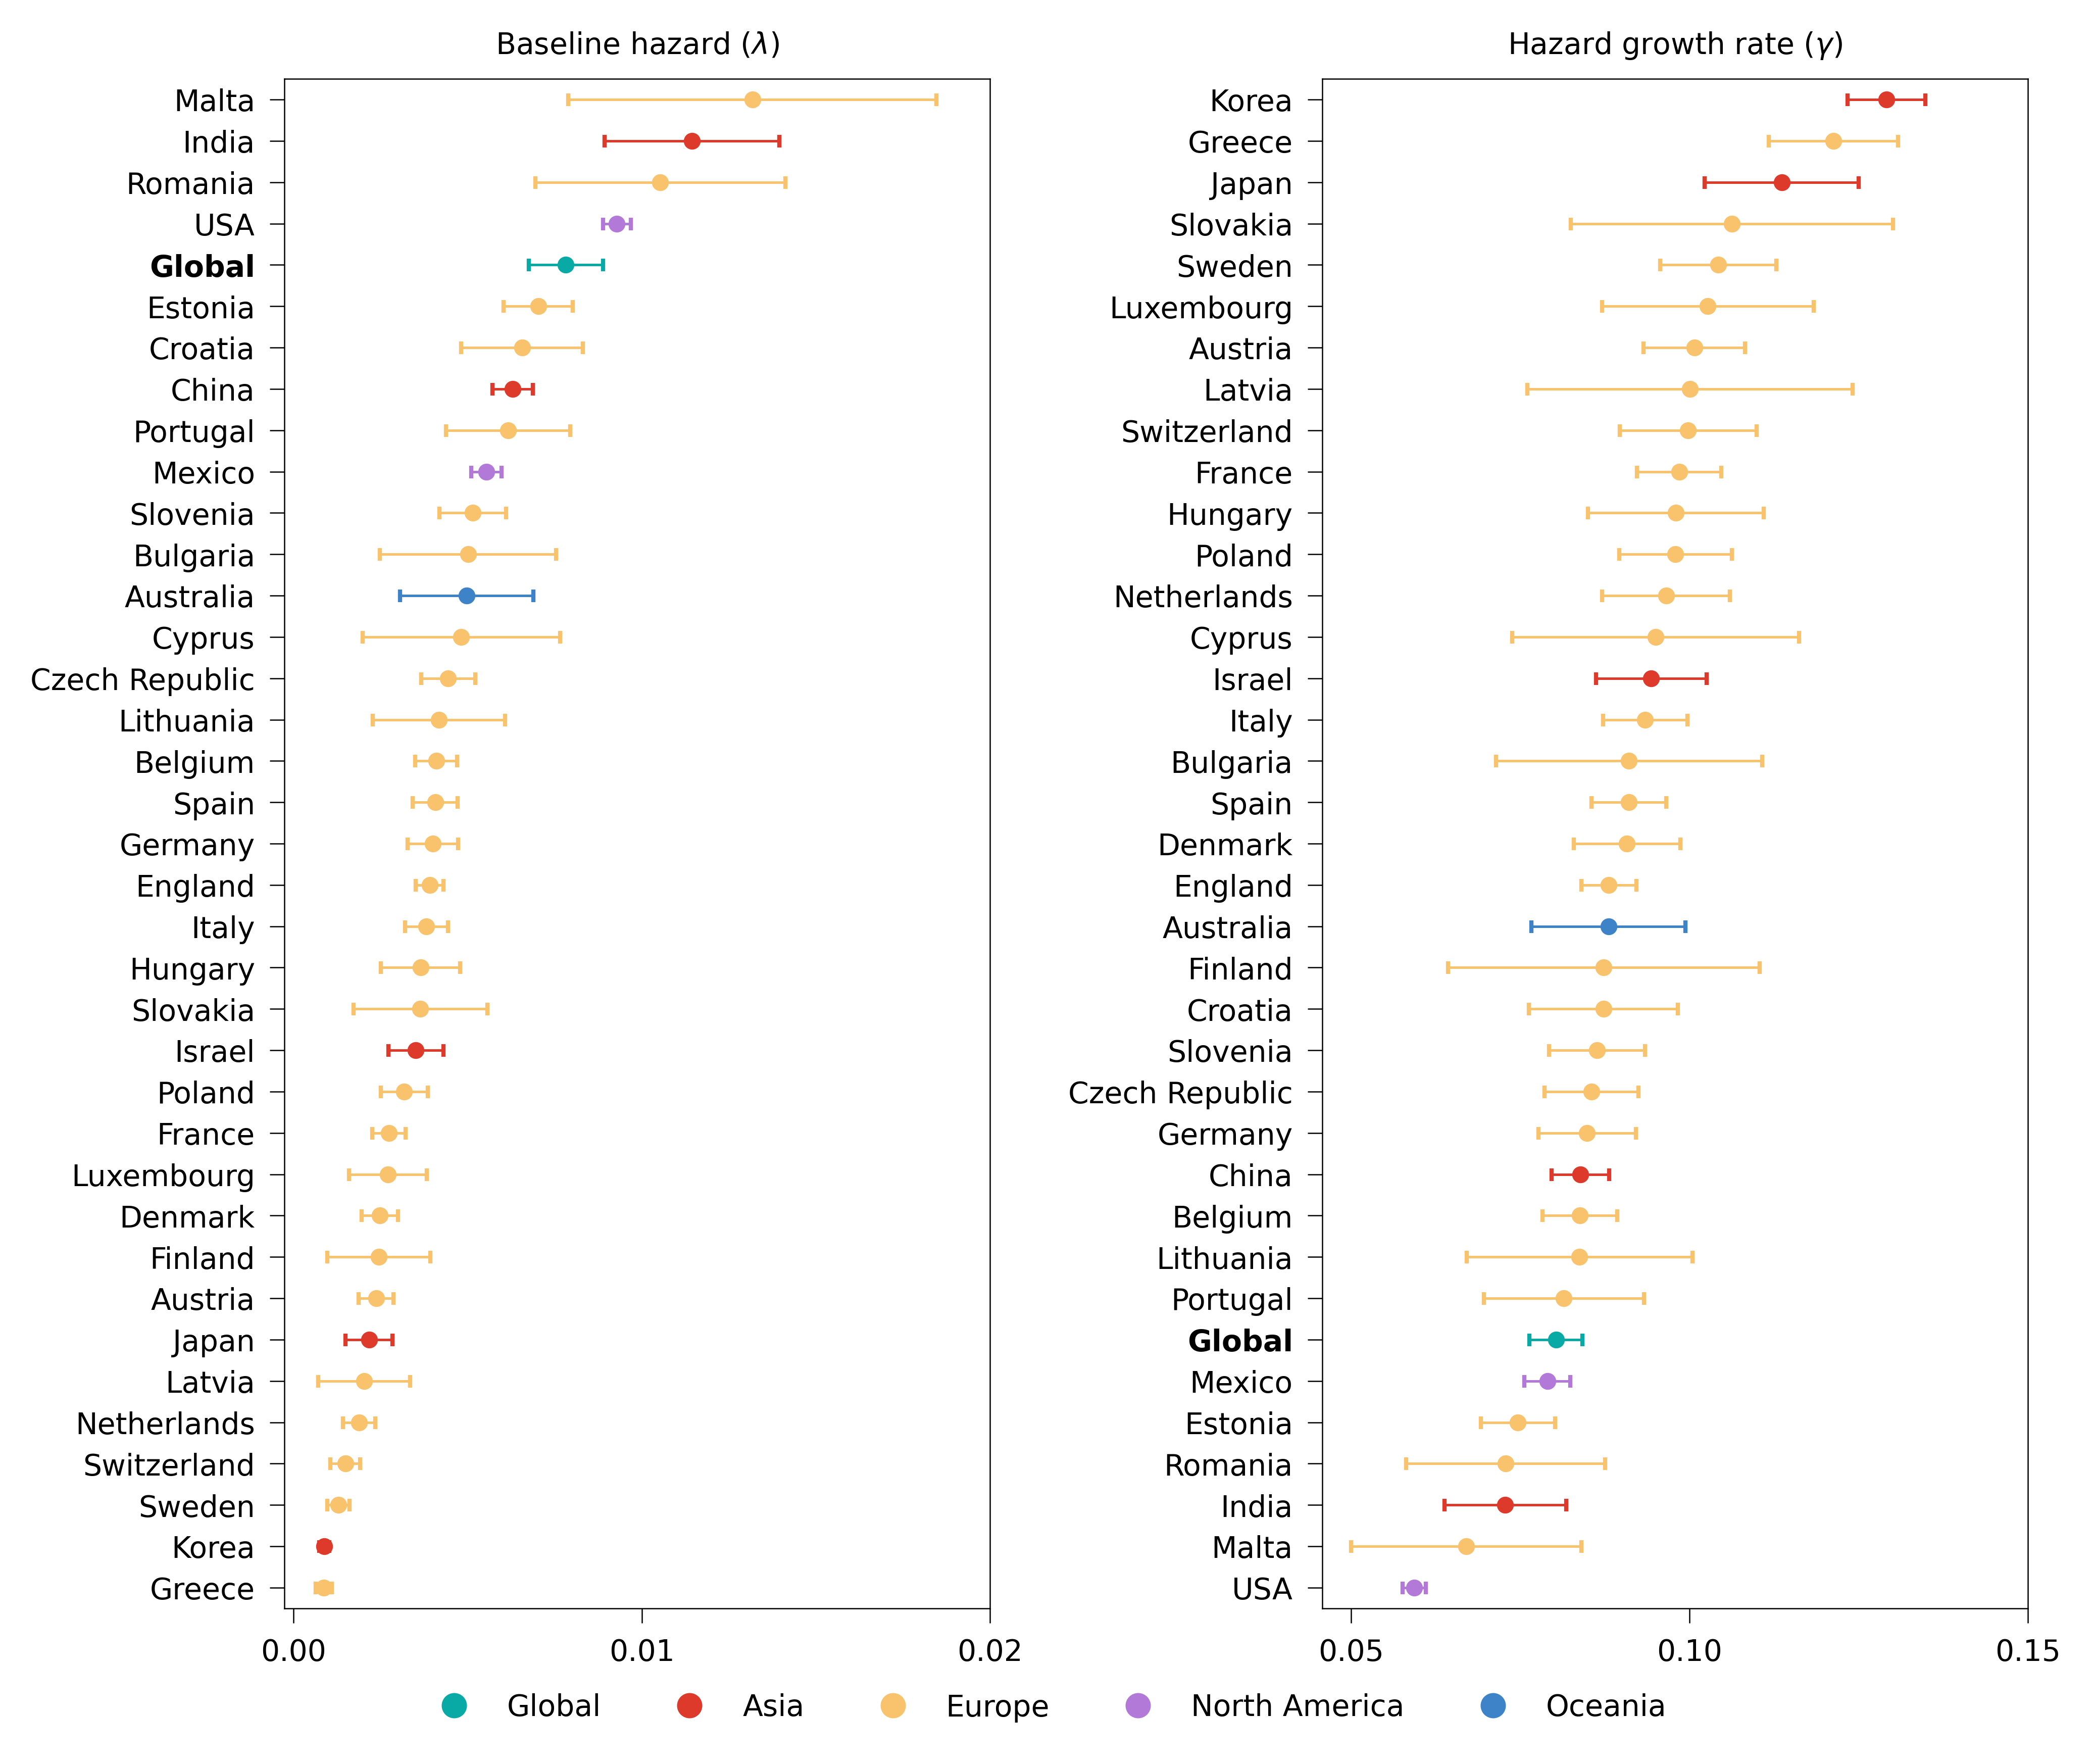

Saved: ../results/f2_gompertz/global_curve_pdf/gompertz_param_forest_combined.pdf


In [27]:
# (14) Forest plots for Gompertz parameters by country (with 95% CI)
import matplotlib.pyplot as plt
import numpy as np

if "pars_all" not in globals() or pars_all is None or pars_all.empty:
    print("pars_all is empty. Run the fitting cells first.")
else:
    dfp = pars_all.copy()
    dfp = dfp.dropna(subset=["gamma_est", "gamma_se", "lambda_est", "lambda_se", "continent"])
    if dfp.empty:
        print("No parameter rows with SE available.")
    else:
        # Global row from pop-weighted params (step 13)
        global_row = None
        if "global_params_df_w" in globals() and isinstance(global_params_df_w, pd.DataFrame):
            if not global_params_df_w.empty:
                global_row = global_params_df_w.copy()
        if global_row is None:
            global_path = os.path.join(TAB_DIR, "global_popweight_params.csv")
            if os.path.exists(global_path):
                global_row = pd.read_csv(global_path)

        if global_row is not None and not global_row.empty:
            needed = {"gamma_est", "gamma_se", "lambda_est", "lambda_se"}
            if not needed.issubset(set(global_row.columns)):
                global_row = None
            else:
                global_row = global_row.assign(country="Global", continent="Global")

        dfp = dfp.assign(
            gamma_l=dfp["gamma_est"] - 1.96 * dfp["gamma_se"],
            gamma_u=dfp["gamma_est"] + 1.96 * dfp["gamma_se"],
            lambda_l=dfp["lambda_est"] - 1.96 * dfp["lambda_se"],
            lambda_u=dfp["lambda_est"] + 1.96 * dfp["lambda_se"],
        )
        if global_row is not None and not global_row.empty:
            global_row = global_row.assign(
                gamma_l=global_row["gamma_est"] - 1.96 * global_row["gamma_se"],
                gamma_u=global_row["gamma_est"] + 1.96 * global_row["gamma_se"],
                lambda_l=global_row["lambda_est"] - 1.96 * global_row["lambda_se"],
                lambda_u=global_row["lambda_est"] + 1.96 * global_row["lambda_se"],
            )
            dfp = pd.concat([dfp, global_row], ignore_index=True)

        conts = dfp["continent"].astype(str).unique().tolist()
        cmap = plt.get_cmap("tab10")
        cont_colors = {c: cmap(i % 10) for i, c in enumerate(conts)}
        cont_colors.update({
            "Europe": "#F9C26C",
            "Asia": "#DD3A2C",
            "North America": "#B279D8",
            "Oceania": "#3E83C7",
            "Global": "#09AAA5",
        })

        # Combined two-parameter forest plot
        df_lambda = dfp.sort_values("lambda_est", ascending=False).reset_index(drop=True)
        df_gamma = dfp.sort_values("gamma_est", ascending=False).reset_index(drop=True)

        fig, axes = plt.subplots(ncols=2, figsize=(7, 6), dpi=600)
        panels = [
            (axes[0], df_lambda, "lambda_est", "lambda_l", "lambda_u", r"Baseline hazard ($\lambda$)", [0.00, 0.01, 0.02]),
            (axes[1], df_gamma, "gamma_est", "gamma_l", "gamma_u", r"Hazard growth rate ($\gamma$)", [0.05, 0.10, 0.15]),
        ]
        for ax, df_plot, est_col, lo_col, hi_col, title, xticks in panels:
            y = np.arange(len(df_plot))[::-1]
            y_labels = df_plot["country"].astype(str).tolist()
            for i, row in df_plot.iterrows():
                c = cont_colors.get(str(row["continent"]), "#7A7A7A")
                ax.errorbar(
                    row[est_col],
                    y[i],
                    xerr=[[row[est_col] - row[lo_col]], [row[hi_col] - row[est_col]]],
                    fmt="o",
                    color=c,
                    ecolor=c,
                    elinewidth=0.6,
                    capsize=1.5,
                    markersize=3,
                )
            ax.set_title(title, fontsize=7)
            ax.set_xticks(xticks)
            ax.grid(False)
            ax.tick_params(axis="x", labelsize=7, width=0.3)
            ax.tick_params(axis="y", labelsize=7, width=0.3)
            for spine in ax.spines.values():
                spine.set_linewidth(0.3)
            ax.set_yticks(y)
            ax.set_yticklabels(y_labels, fontsize=7)
            ax.set_ylim(-0.5, len(df_plot) - 0.5)
            for t in ax.get_yticklabels():
                if t.get_text() == "Global":
                    t.set_fontweight("bold")

        legend_order = ["Global", "Asia", "Europe", "North America", "Oceania"]
        legend_handles = [
            plt.Line2D([0], [0], marker="o", color=cont_colors[c], linestyle="", markersize=5, label=c)
            for c in legend_order
            if c in cont_colors
        ]
        fig.legend(
            handles=legend_handles, loc="lower center", frameon=False, fontsize=7, ncol=5,
            bbox_to_anchor=(0.5, 0.03)
        )
        plt.tight_layout(rect=[0, 0.05, 1, 1])
        out_path = os.path.join(GLOBAL_FIGDIR, "gompertz_param_forest_combined.pdf")
        plt.savefig(out_path, dpi=600)
        plt.show()
        print("Saved:", out_path)